# 🏠 Housing Price — Model Training & Evaluation
Sử dụng `BasicHousingPreprocessor` (có ward extraction) trong pipeline đầy đủ:
load raw → split → preprocess → encode/scale → KFold CV → train 7 models → đánh giá + permutation importance + lưu pkl.

## 0. Cài đặt thư viện

In [1]:
# !pip install lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib --quiet

## 1. Import & Cấu hình

In [3]:
import sys, warnings, joblib
from pathlib import Path
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.preprocessing import (
    BasicHousingPreprocessor, ColumnDropper,
    build_preprocessing_pipeline, prepare_model_data,
    TARGET_COL, DROP_COLS, extract_ward, extract_district,
    VALID_WARD_KEYS_ALL_HCM, KNOWN_WARD_COORDS,
)

DATA_PATH    = PROJECT_ROOT / "data" / "raw" / "data_public.csv"
MODEL_DIR    = PROJECT_ROOT / "artifacts" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_FOLDS      = 5
LOG_TARGET   = True
LOG_CLIP_MAX = 25
N_PERM_REPS  = 20   # permutation importance repeats

# Models to save as pkl (tree + boosting)
SAVE_MODELS  = {"Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"}
# Models to run permutation importance on (same set, minus Gradient Boosting for speed)
PERM_MODELS  = {"Random Forest", "XGBoost", "LightGBM", "Gradient Boosting"}

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)
print("✅ Import xong")


✅ Import xong


## 2. Load dữ liệu thô & Train/Test split
Split **trước** preprocessing để tránh data leakage.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
train_raw, test_raw = train_test_split(df_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_raw = train_raw.reset_index(drop=True)
test_raw  = test_raw.reset_index(drop=True)
print(f"Train: {train_raw.shape}  |  Test: {test_raw.shape}")


Raw shape: (51304, 28)
Train: (41043, 28)  |  Test: (10261, 28)


## 3. Ward extraction — kiểm tra trước preprocessing

In [4]:
# Demo extract_ward trên sample Location
sample_locs = [
    "Phường Thảo Điền, TP. Hồ Chí Minh",
    "Xã Bình Hưng, Huyện Bình Chánh, TP. HCM",
    "Phường Hiệp Bình Phước, TP. Thủ Đức, TP.HCM",
    "Phường An Phú, Quận 2, TP. Hồ Chí Minh",
    "Xã Vĩnh Lộc A, Huyện Bình Chánh, TP.HCM",
    "Đường Lê Lợi, Quận 1, TP. HCM",      # không có ward → None
    "Hà Nội",                               # ngoài HCM → None
]
print(f"{'Location':<55} District                  Ward")
print("-" * 100)
for loc in sample_locs:
    d = extract_district(loc)
    w = extract_ward(loc)
    print(f"{loc:<55} {str(d):<25} {w}")

print(f"\nTổng số ward trong VALID_WARD_KEYS_ALL_HCM : {len(VALID_WARD_KEYS_ALL_HCM)}")
print(f"Số ward có static coords (KNOWN_WARD_COORDS): {len(KNOWN_WARD_COORDS)}")


Location                                                District                  Ward
----------------------------------------------------------------------------------------------------
Phường Thảo Điền, TP. Hồ Chí Minh                       Phường Thảo Điền          Phường Thảo Điền
Xã Bình Hưng, Huyện Bình Chánh, TP. HCM                 Huyện Bình Chánh          Xã Bình Hưng
Phường Hiệp Bình Phước, TP. Thủ Đức, TP.HCM             Phường Hiệp Bình Phước    Phường Hiệp Bình Phước
Phường An Phú, Quận 2, TP. Hồ Chí Minh                  Quận 2                    Phường An Phú
Xã Vĩnh Lộc A, Huyện Bình Chánh, TP.HCM                 Huyện Bình Chánh          Xã Vĩnh Lộc A
Đường Lê Lợi, Quận 1, TP. HCM                           Quận 1                    None
Hà Nội                                                  Khác                      None

Tổng số ward trong VALID_WARD_KEYS_ALL_HCM : 122
Số ward có static coords (KNOWN_WARD_COORDS): 94


In [5]:
# Xem phân phối ward trong train data
if "Location" in train_raw.columns:
    ward_series = train_raw["Location"].apply(extract_ward)
    n_with_ward = ward_series.notna().sum()
    print(f"Rows có ward được trích: {n_with_ward:,} / {len(train_raw):,} ({n_with_ward/len(train_raw)*100:.1f}%)")
    print("\nTop 20 wards phổ biến nhất:")
    print(ward_series.value_counts().head(20).to_string())


Rows có ward được trích: 19,169 / 41,043 (46.7%)

Top 20 wards phổ biến nhất:
Location
Phường Tân Phú            1024
Phường An Phú              857
Phường Long Bình           708
Phường 12                  628
Phường Phú Hữu             608
Phường Long Trường         519
Phường Hiệp Bình Chánh     513
Phường Phú Mỹ              454
Phường Sơn Kỳ              427
Phường Long Thạnh Mỹ       418
Phường 14                  403
Xã Phước Kiến              394
Xã Hiệp Phước              392
Phường Bình Trị Đông       373
Phường Phú Thọ Hòa         365
Phường 13                  361
Phường Tấn Hưng            357
Phường Phú Thuận           354
Phường Phước Long B        351
Phường Trường Thạnh        330


## 4. Preprocessing
`fit_transform` trên train → `.transform` trên test. Ward được dùng để fill lat/lon chính xác hơn rồi drop.

In [6]:
preprocessor = BasicHousingPreprocessor(target_col=TARGET_COL)
train_clean  = preprocessor.fit_transform(train_raw)
test_clean   = preprocessor.transform(test_raw)

preview_drop = [c for c in DROP_COLS if c != "Location"] + ["price_per_m2"]
dropper      = ColumnDropper(preview_drop)
train_clean  = dropper.transform(train_clean)
test_clean   = dropper.transform(test_clean)

print(f"Train clean: {train_clean.shape}  |  Test clean: {test_clean.shape}")
print(f"Columns    : {train_clean.columns.tolist()}")
print(f"Missing    : train={train_clean.isnull().sum().sum()} | test={test_clean.isnull().sum().sum()}")
print(f"\nWard coord lookup học từ train: {len(preprocessor.ward_coordinate_lookup_)} wards")


Train clean: (40129, 18)  |  Test clean: (10014, 18)
Columns    : ['Price', 'Area', 'Location', 'Property Type', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors', 'Position', 'Direction', 'Alley Width', 'Road Type', 'Latitude', 'Longitude', 'Agent Listing Count', 'District', 'distance_to_center']
Missing    : train=0 | test=0

Ward coord lookup học từ train: 33 wards


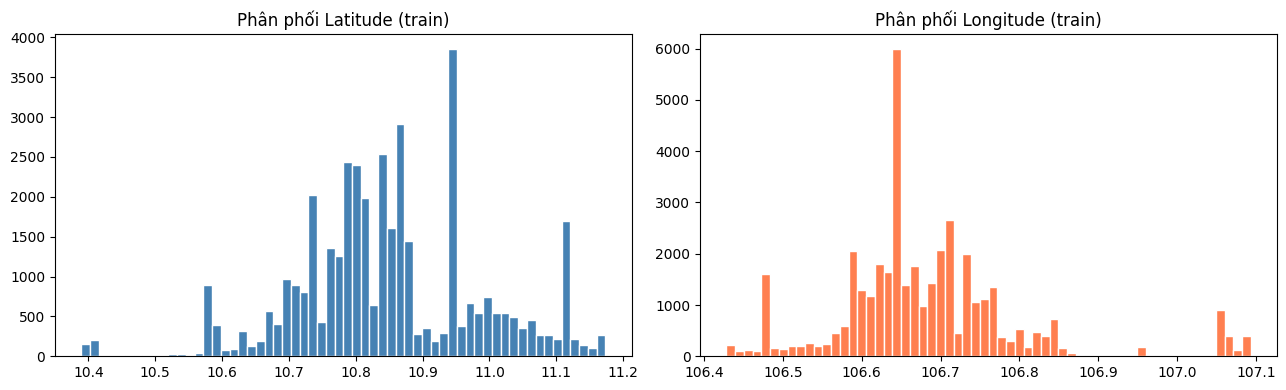

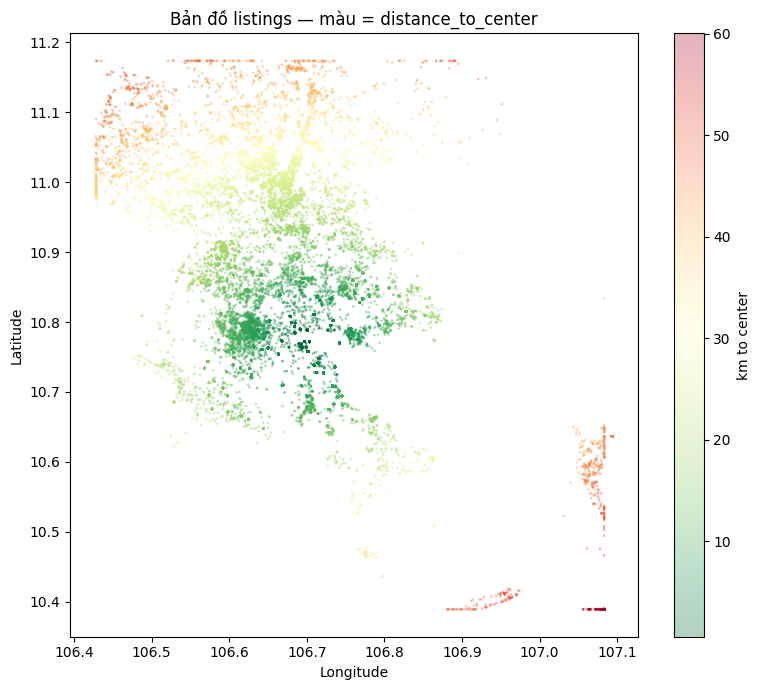

In [7]:
# Kiểm tra fill quality — phân phối lat/lon
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_clean["Latitude"].dropna(),  bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Phân phối Latitude (train)")
axes[1].hist(train_clean["Longitude"].dropna(), bins=60, color="coral",     edgecolor="white")
axes[1].set_title("Phân phối Longitude (train)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(train_clean["Longitude"], train_clean["Latitude"],
                c=train_clean["distance_to_center"], cmap="RdYlGn_r", s=1, alpha=0.3)
plt.colorbar(sc, ax=ax, label="km to center")
ax.set_title("Bản đồ listings — màu = distance_to_center")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()


## 5. Tách X / y — log1p transform target

In [8]:
X_train_df, y_train_raw = prepare_model_data(train_clean, target_col=TARGET_COL)
X_test_df,  y_test_raw  = prepare_model_data(test_clean,  target_col=TARGET_COL)

y_train      = np.log1p(y_train_raw) if LOG_TARGET else y_train_raw.copy()
y_test       = np.log1p(y_test_raw)  if LOG_TARGET else y_test_raw.copy()
y_train_real = y_train_raw.copy()
y_test_real  = y_test_raw.copy()

print(f"X_train: {X_train_df.shape}  |  X_test: {X_test_df.shape}")
print(f"y_train  mean/std: {y_train.mean():.3f} / {y_train.std():.3f}  (log space)")


X_train: (40129, 17)  |  X_test: (10014, 17)
y_train  mean/std: 9.098 / 1.418  (log space)


## 6. Encode & Scale (One-Hot + StandardScaler)

In [9]:
encode_pipeline = build_preprocessing_pipeline(X_train_df)
X_train = encode_pipeline.fit_transform(X_train_df, y_train)
X_test  = encode_pipeline.transform(X_test_df)

try:
    feature_names = list(encode_pipeline.named_steps["encode_scale"].get_feature_names_out())
except Exception:
    feature_names = [f"f_{i}" for i in range(X_train.shape[1])]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Feature sample: {feature_names[:8]} ...")


X_train: (40129, 82)  |  X_test: (10014, 82)
Feature sample: ['numeric__Area', 'numeric__Width', 'numeric__Length', 'numeric__Bedrooms', 'numeric__Bathrooms', 'numeric__Floors', 'numeric__Alley Width', 'numeric__Agent Listing Count'] ...


## 7. Định nghĩa Models

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge"            : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso"            : Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10_000),
    "Random Forest"    : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                    max_depth=5, random_state=RANDOM_STATE),
    "XGBoost"          : XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                                       random_state=RANDOM_STATE, objective="reg:squarederror",
                                       eval_metric="rmse", n_jobs=-1, verbosity=0),
    "LightGBM"         : LGBMRegressor(n_estimators=200, learning_rate=0.1,
                                        random_state=RANDOM_STATE, verbose=-1),
    "Dummy (baseline)" : DummyRegressor(strategy="median"),
}
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Models  : {list(models.keys())}")
print(f"KFold   : {N_FOLDS} folds")


Models  : ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'Dummy (baseline)']
KFold   : 5 folds


## 8. KFold CV + Train + Test Evaluation

In [11]:
metrics_list      = []
model_predictions = {}
fitted_models     = {}

for name, model in models.items():
    print(f"\n{'─'*58}")
    print(f"  {name}")
    print(f"{'─'*58}")
    cv_scores = {"MAE": [], "RMSE": [], "R2": [], "MAPE": []}

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        fm = clone(model); fm.fit(X_tr, y_tr.values)
        val_log  = np.clip(fm.predict(X_val), 0, LOG_CLIP_MAX)
        val_real = np.expm1(val_log) if LOG_TARGET else val_log
        yv_real  = np.expm1(y_val.values) if LOG_TARGET else y_val.values

        cv_scores["MAE"].append(mean_absolute_error(yv_real, val_real))
        cv_scores["RMSE"].append(np.sqrt(mean_squared_error(yv_real, val_real)))
        cv_scores["R2"].append(r2_score(yv_real, val_real))
        cv_scores["MAPE"].append(mean_absolute_percentage_error(yv_real, val_real) * 100)
        print(f"    Fold {fold}: MAE={cv_scores['MAE'][-1]:,.0f}  RMSE={cv_scores['RMSE'][-1]:,.0f}"
              f"  R²={cv_scores['R2'][-1]:.4f}  MAPE={cv_scores['MAPE'][-1]:.2f}%")

    cv_mae  = np.mean(cv_scores["MAE"])
    cv_rmse = np.mean(cv_scores["RMSE"])
    cv_r2   = np.mean(cv_scores["R2"])
    cv_mape = np.mean(cv_scores["MAPE"])
    print(f"  → CV avg : MAE={cv_mae:,.0f}  RMSE={cv_rmse:,.0f}  R²={cv_r2:.4f}  MAPE={cv_mape:.2f}%")

    final = clone(model); final.fit(X_train, y_train.values)
    fitted_models[name] = final

    pred_log  = np.clip(final.predict(X_test), 0, LOG_CLIP_MAX)
    pred_real = np.expm1(pred_log) if LOG_TARGET else pred_log

    mae  = mean_absolute_error(y_test_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    r2   = r2_score(y_test_real, pred_real)
    mape = mean_absolute_percentage_error(y_test_real, pred_real) * 100
    print(f"  → TEST   : MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}  MAPE={mape:.2f}%")

    metrics_list.append({
        "Model": name,
        "CV MAE": cv_mae,   "CV RMSE": cv_rmse,   "CV R²": cv_r2,   "CV MAPE (%)": cv_mape,
        "Test MAE": mae,    "Test RMSE": rmse,     "Test R²": r2,    "Test MAPE (%)": mape,
    })
    model_predictions[name] = {"pred_log": pred_log, "pred_real": pred_real}

metrics_df = pd.DataFrame(metrics_list)
print("\n" + "="*65)
display(metrics_df.set_index("Model"))



──────────────────────────────────────────────────────────
  Linear Regression
──────────────────────────────────────────────────────────
    Fold 1: MAE=27,452  RMSE=88,095  R²=-0.1745  MAPE=112.45%
    Fold 2: MAE=25,346  RMSE=84,632  R²=-0.1524  MAPE=110.38%
    Fold 3: MAE=25,486  RMSE=82,956  R²=-0.1810  MAPE=110.93%
    Fold 4: MAE=27,527  RMSE=90,655  R²=-0.1611  MAPE=112.56%
    Fold 5: MAE=26,903  RMSE=87,521  R²=-0.1734  MAPE=113.25%
  → CV avg : MAE=26,543  RMSE=86,772  R²=-0.1685  MAPE=111.91%
  → TEST   : MAE=26,180  RMSE=84,151  R²=-0.1446  MAPE=111.45%

──────────────────────────────────────────────────────────
  Ridge
──────────────────────────────────────────────────────────
    Fold 1: MAE=27,452  RMSE=88,099  R²=-0.1746  MAPE=112.47%
    Fold 2: MAE=25,348  RMSE=84,621  R²=-0.1521  MAPE=110.40%
    Fold 3: MAE=25,486  RMSE=82,959  R²=-0.1811  MAPE=110.91%
    Fold 4: MAE=27,534  RMSE=90,638  R²=-0.1607  MAPE=112.57%
    Fold 5: MAE=26,902  RMSE=87,532  R²=-0.1737  M

,CV MAE,CV RMSE,CV R²,CV MAPE (%),Test MAE,Test RMSE,Test R²,Test MAPE (%)
Model,,,,,,,,
Linear Regression,"26,542.777","86,771.831",-0.168,111.913,"26,179.718","84,150.714",-0.145,111.452
Ridge,"26,544.461","86,769.891",-0.168,111.905,"26,184.717","84,157.840",-0.145,111.457
Lasso,"26,647.839","83,658.991",-0.087,118.243,"26,563.525","82,683.502",-0.105,118.710
Random Forest,"21,435.358","72,217.755",0.190,91.251,"21,124.662","71,433.602",0.175,89.956
Gradient Boosting,"21,893.970","74,201.892",0.145,76.231,"21,722.218","73,118.979",0.136,76.065
XGBoost,"21,754.979","73,957.133",0.151,75.651,"21,598.496","72,949.189",0.140,74.721
LightGBM,"21,848.088","74,235.250",0.144,75.637,"21,667.774","73,320.373",0.131,75.351
Dummy (baseline),"27,726.503","83,852.691",-0.091,126.190,"27,543.885","82,237.202",-0.093,127.846


## 9. So sánh Metrics

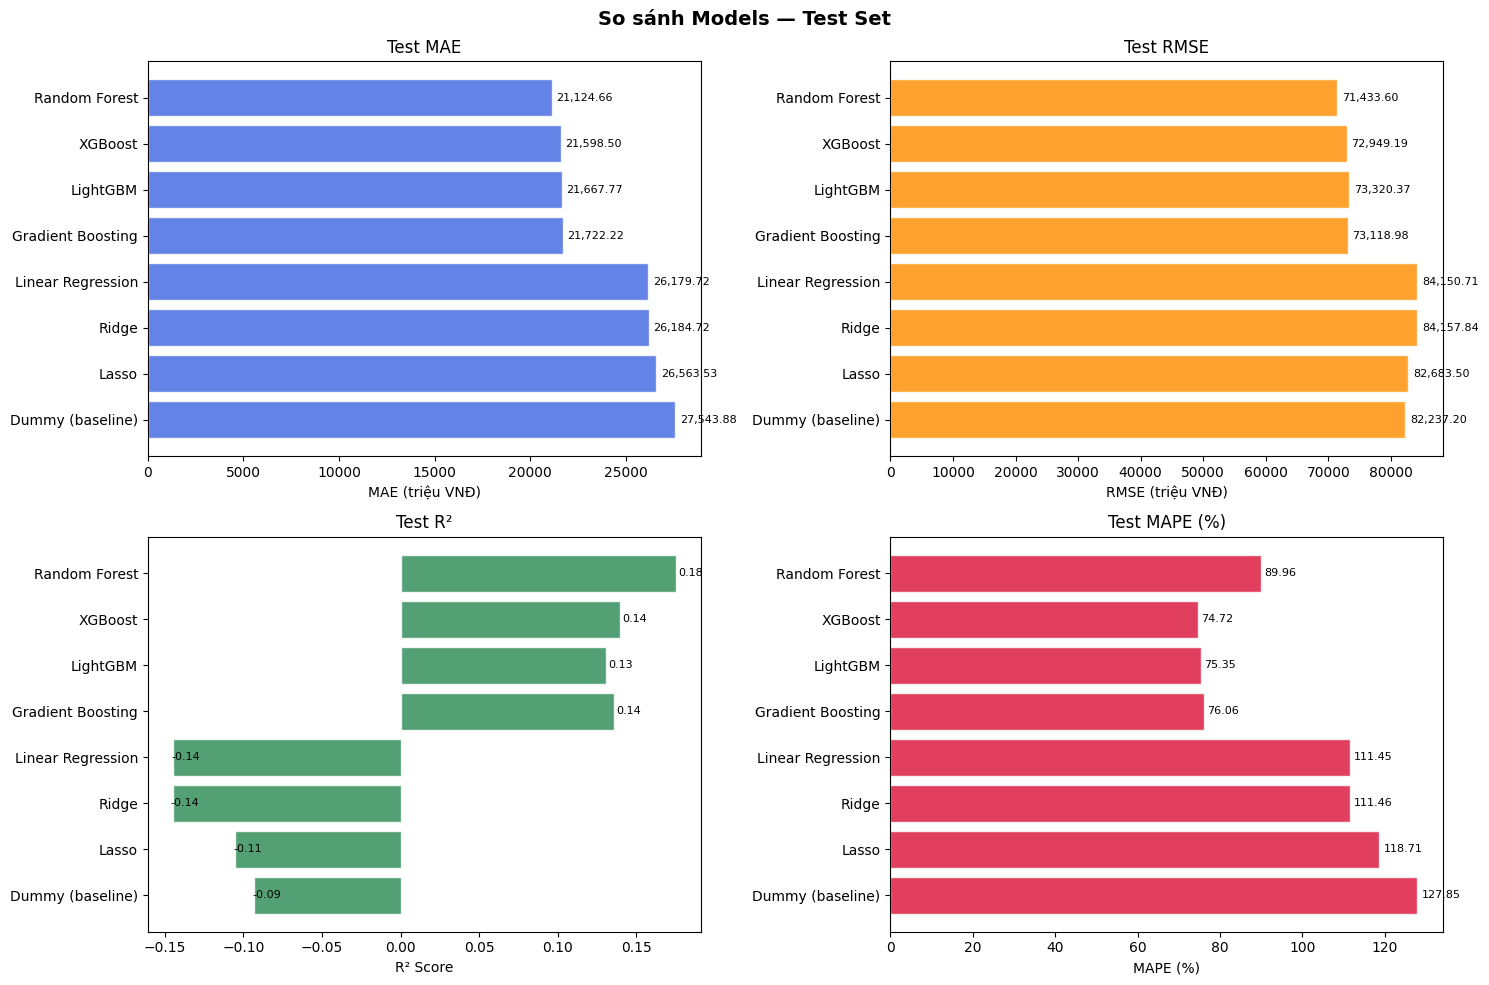

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metric_pairs = [
    ("Test MAE",      "MAE (triệu VNĐ)",   "royalblue"),
    ("Test RMSE",     "RMSE (triệu VNĐ)",  "darkorange"),
    ("Test R²",       "R² Score",           "seagreen"),
    ("Test MAPE (%)", "MAPE (%)",           "crimson"),
]
order = metrics_df.sort_values("Test MAE")["Model"].tolist()
for ax, (metric, ylabel, color) in zip(axes.flat, metric_pairs):
    vals = metrics_df.set_index("Model").loc[order, metric]
    bars = ax.barh(order, vals, color=color, alpha=0.82, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,.2f}", va="center", fontsize=8)
    ax.set_xlabel(ylabel); ax.set_title(metric); ax.invert_yaxis()
plt.suptitle("So sánh Models — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 10. Top 5 Errors Lớn Nhất

In [13]:
# ── Top 5 errors lớn nhất ──────────────────────────────────────────
error_rows = []
for name, pd_ in model_predictions.items():
    errors = np.abs(y_test_real.values - pd_["pred_real"])
    top_5_idx = np.argsort(errors)[-5:][::-1]
    for rank, idx in enumerate(top_5_idx, 1):
        error_rows.append({
            "Model": name,
            "Rank": rank,
            "Actual": y_test_real.values[idx],
            "Predicted": pd_["pred_real"][idx],
            "Error": errors[idx],
            "Error %": errors[idx] / y_test_real.values[idx] * 100 if y_test_real.values[idx] != 0 else 0
        })

error_df = pd.DataFrame(error_rows)
error_df.sort_values(["Model", "Error"], ascending=[True, False], inplace=True)

# Bảng top 5 errors theo model
print("=== Top 5 Errors Lớn Nhất (tuyệt đối) ===")
for model in sorted(error_df["Model"].unique()):
    model_errors = error_df[error_df["Model"] == model].sort_values("Error", ascending=False).head(5)
    print(f"\n{model}:")
    display(model_errors[["Rank", "Actual", "Predicted", "Error", "Error %"]].style
            .format({"Actual": "{:,.0f}", "Predicted": "{:,.0f}", "Error": "{:,.0f}", "Error %": "{:.1f}%"})
            .background_gradient(subset=["Error"], cmap="Reds"))

=== Top 5 Errors Lớn Nhất (tuyệt đối) ===

Dummy (baseline):


,Rank,Actual,Predicted,Error,Error %
35,1,"750,000","7,000","743,000",99.1%
36,2,"750,000","7,000","743,000",99.1%
37,3,"750,000","7,000","743,000",99.1%
38,4,"750,000","7,000","743,000",99.1%
39,5,"750,000","7,000","743,000",99.1%



Gradient Boosting:


,Rank,Actual,Predicted,Error,Error %
20,1,"750,000","10,328","739,672",98.6%
21,2,"748,000","12,285","735,715",98.4%
22,3,"750,000","14,777","735,223",98.0%
23,4,"750,000","14,847","735,153",98.0%
24,5,"750,000","15,368","734,632",98.0%



Lasso:


...

,Rank,Actual,Predicted,Error,Error %
15,1,"750,000","10,109","739,891",98.7%
16,2,"750,000","11,228","738,772",98.5%
17,3,"750,000","12,546","737,454",98.3%
18,4,"750,000","13,852","736,148",98.2%
19,5,"750,000","14,339","735,661",98.1%



Ridge:


,Rank,Actual,Predicted,Error,Error %
5,1,"365,000","1,734,117","1,369,117",375.1%
6,2,"365,000","1,733,021","1,368,021",374.8%
7,3,"365,000","1,733,021","1,368,021",374.8%
8,4,"240,000","1,420,955","1,180,955",492.1%
9,5,"200,000","1,143,607","943,607",471.8%



XGBoost:


,Rank,Actual,Predicted,Error,Error %
25,1,"750,000","10,810","739,190",98.6%
26,2,"750,000","12,771","737,229",98.3%
27,3,"750,000","13,396","736,604",98.2%
28,4,"750,000","15,659","734,341",97.9%
29,5,"748,000","13,831","734,169",98.2%


## 11. Actual vs Predicted

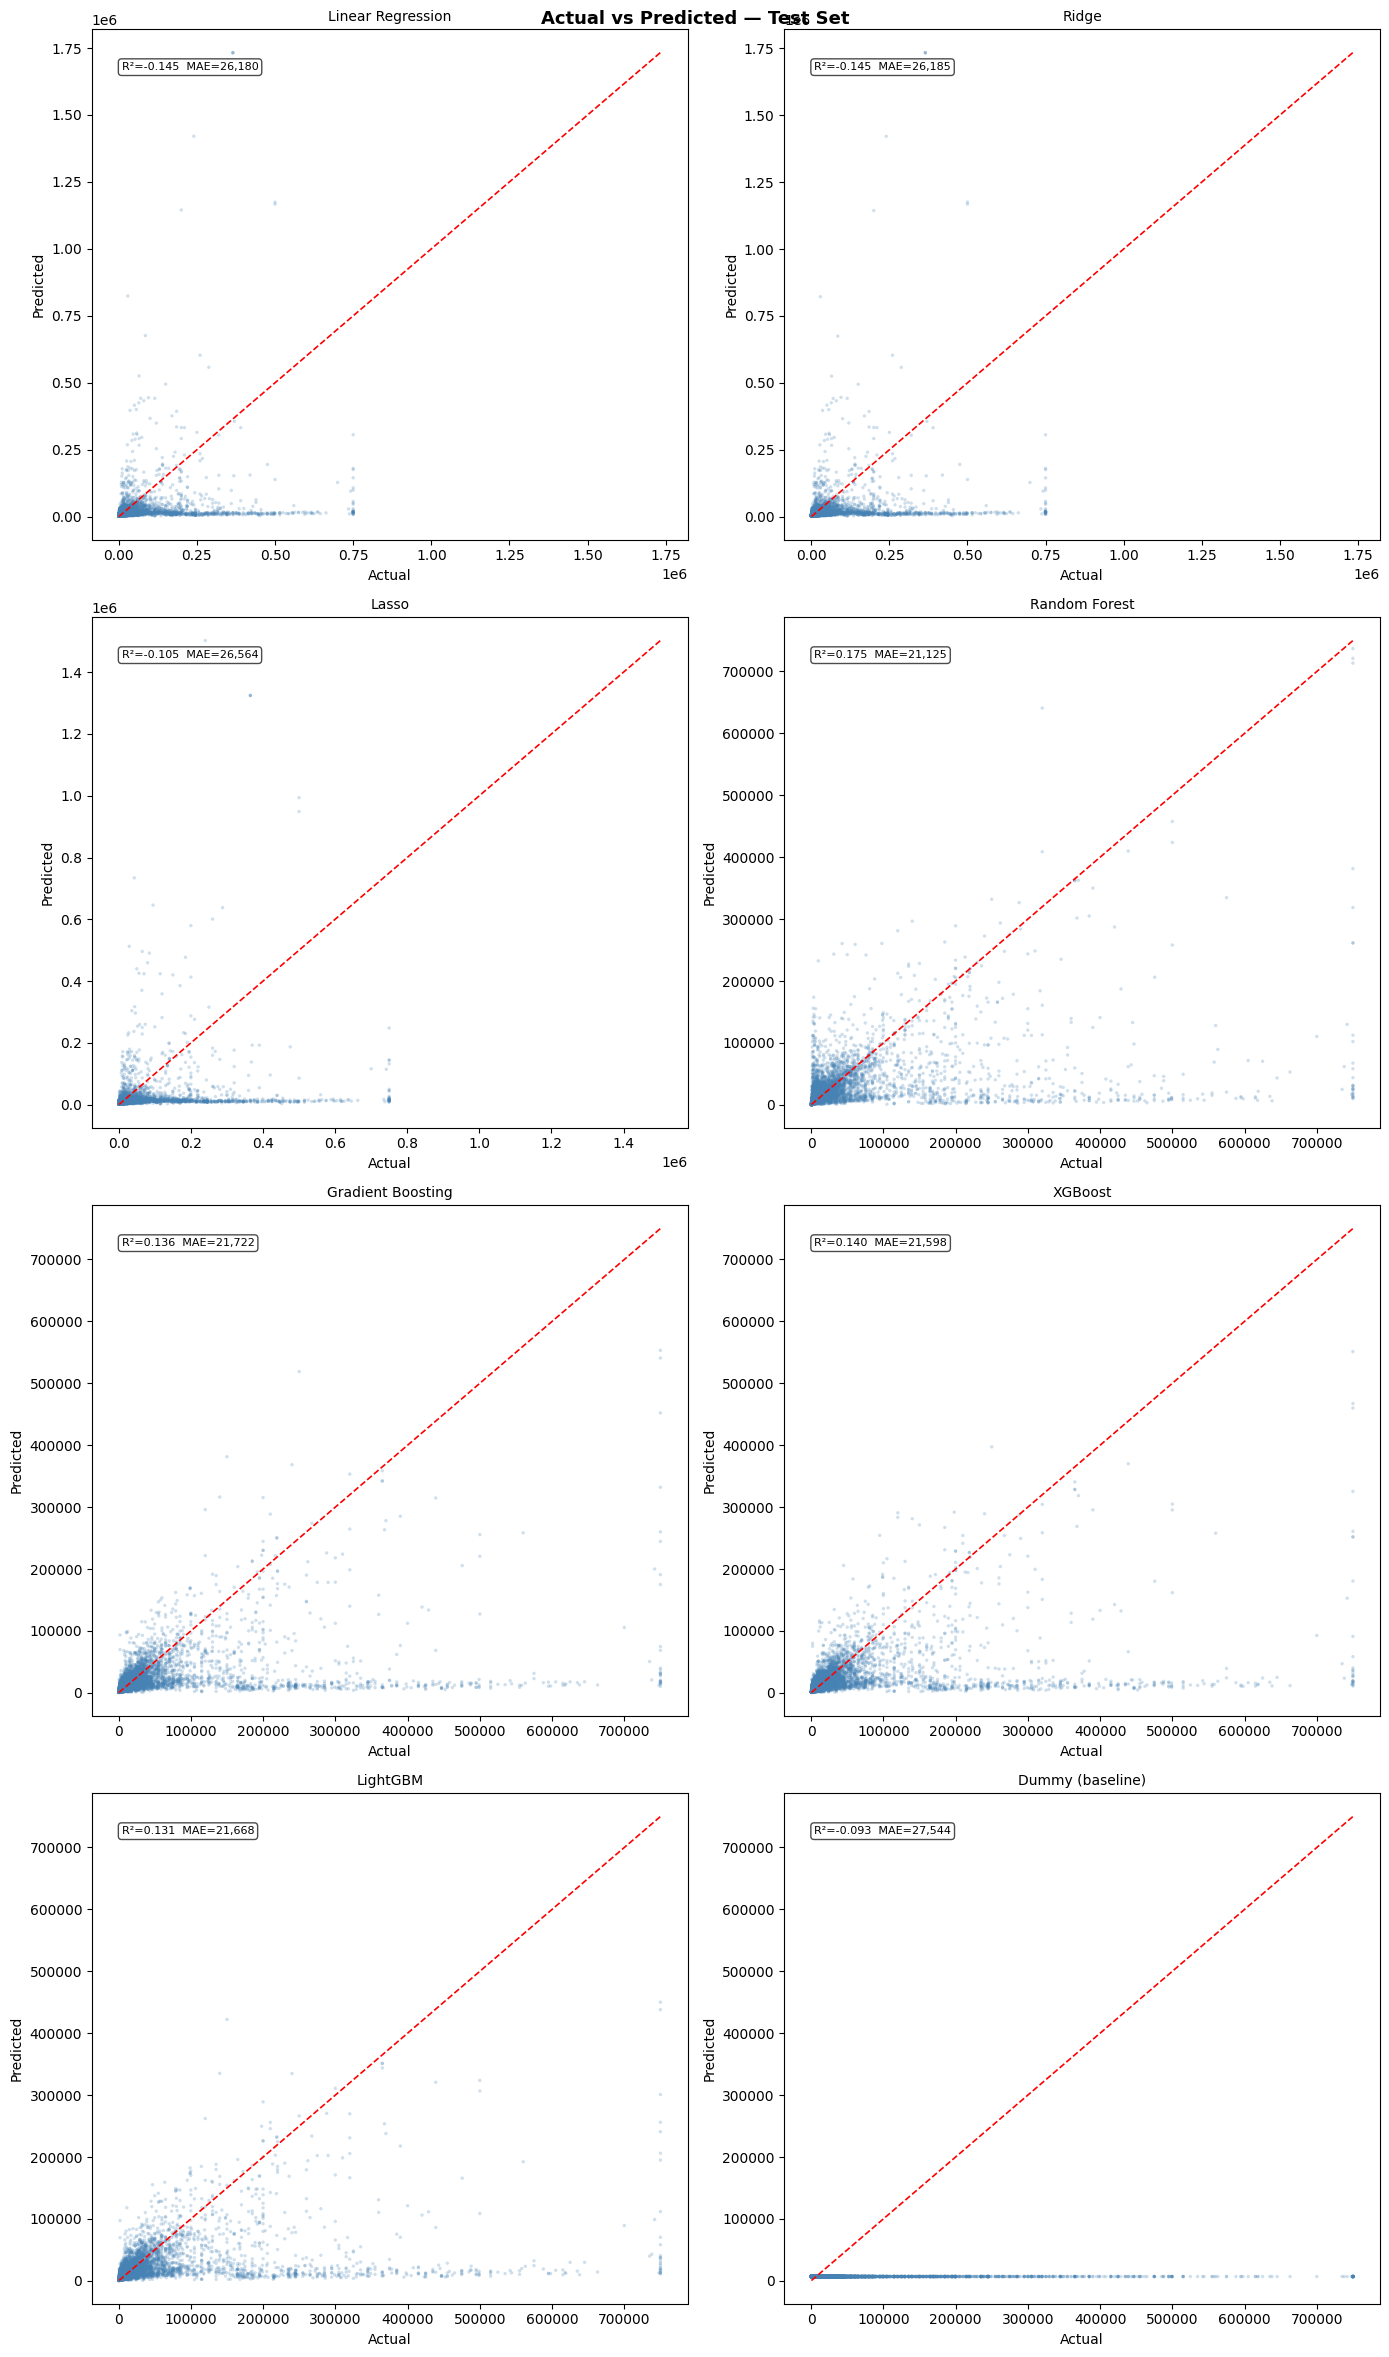

In [14]:
nm = len(model_predictions)
ncols = 2; nrows = (nm + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 6))
axes = axes.flat
for ax, (name, pd_) in zip(axes, model_predictions.items()):
    y_act, y_prd = y_test_real, pd_["pred_real"]
    ax.scatter(y_act, y_prd, alpha=0.25, s=6, color="steelblue", edgecolors="none")
    lo, hi = min(y_act.min(), y_prd.min()), max(y_act.max(), y_prd.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
    ax.set_title(name, fontsize=10); ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.text(0.05, 0.92, f"R²={r2_score(y_act, y_prd):.3f}  MAE={mean_absolute_error(y_act, y_prd):,.0f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
for ax in list(axes)[nm:]: ax.set_visible(False)
plt.suptitle("Actual vs Predicted — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 12. Phân phối Residuals

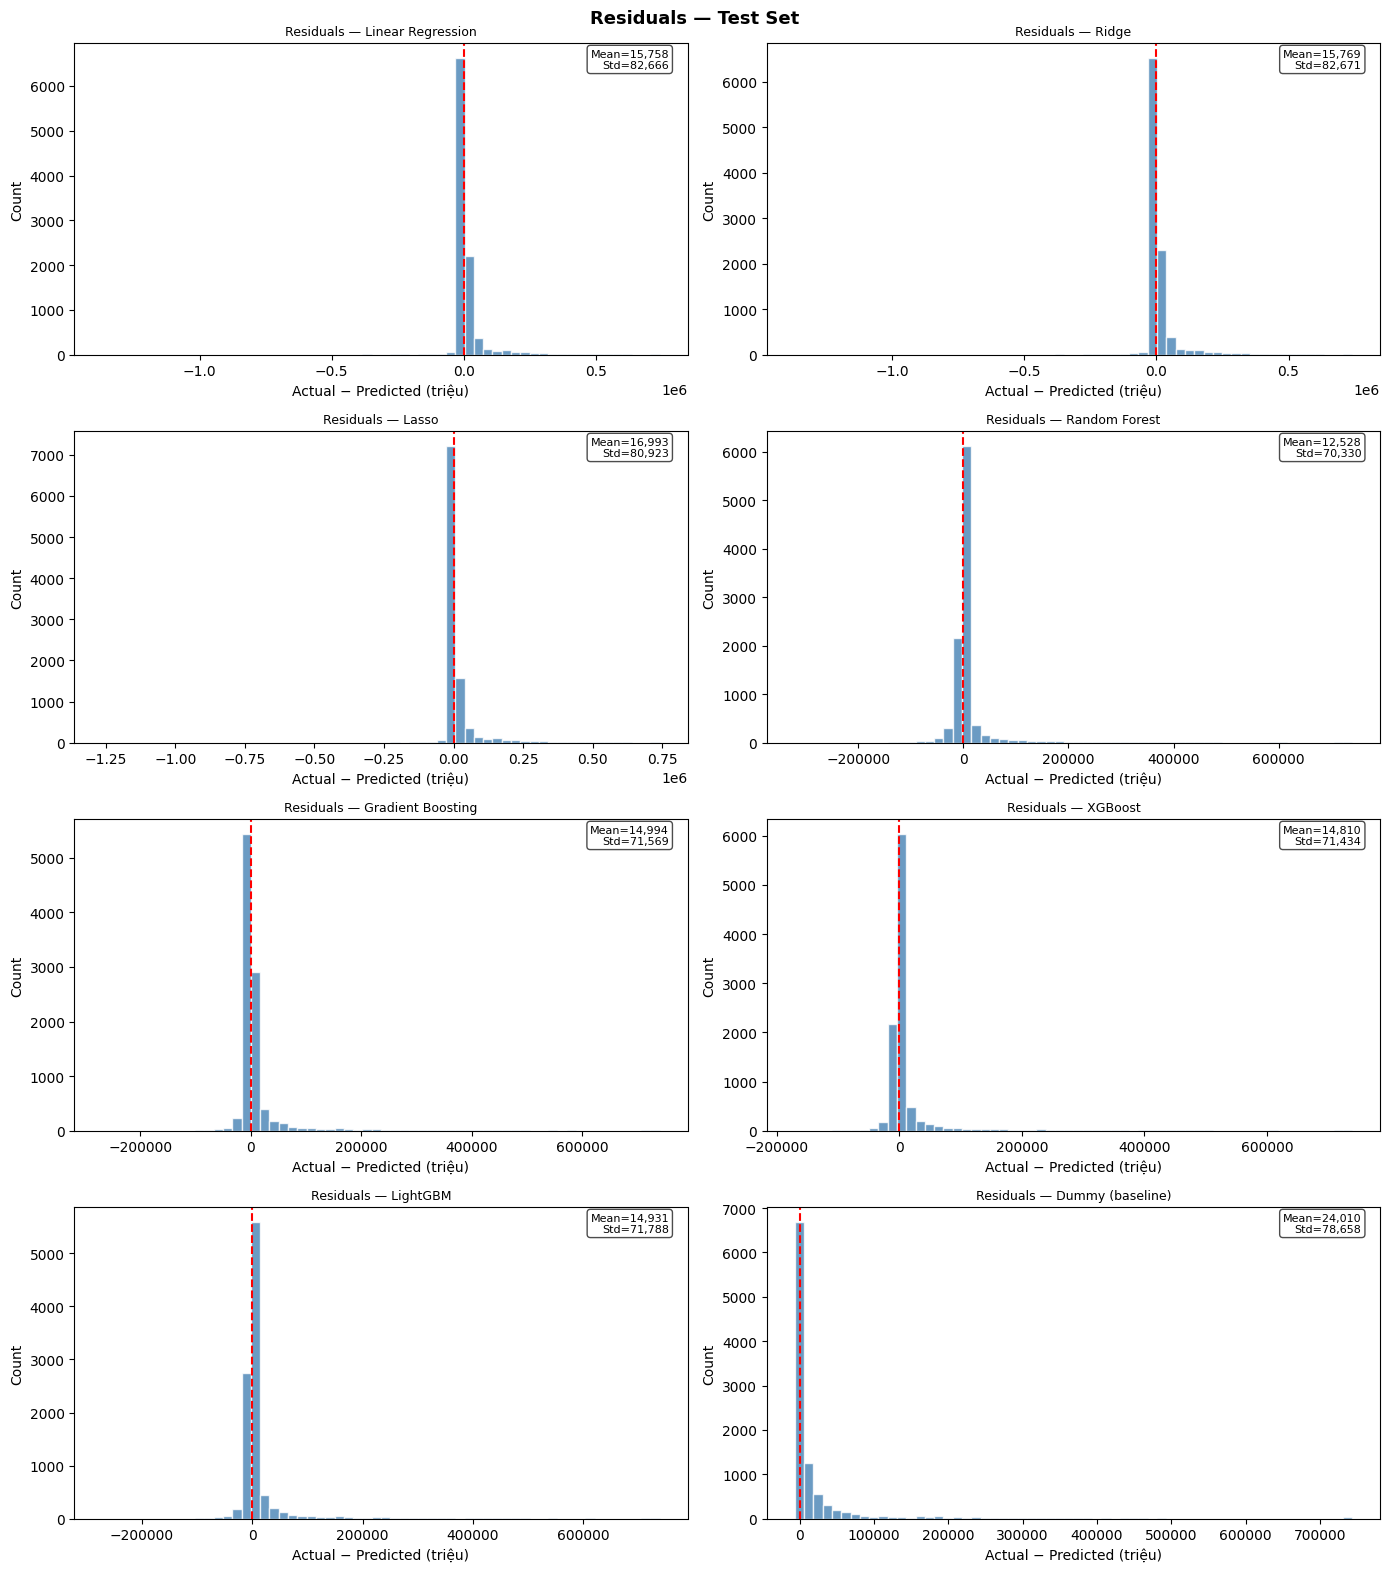

In [15]:
nm = len(model_predictions)
nrows = (nm + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows * 4))
axes = axes.flat
for ax, (name, pd_) in zip(axes, model_predictions.items()):
    res = y_test_real - pd_["pred_real"]
    ax.hist(res, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", lw=1.5, ls="--")
    ax.set_title(f"Residuals — {name}", fontsize=9)
    ax.set_xlabel("Actual − Predicted (triệu)"); ax.set_ylabel("Count")
    ax.text(0.97, 0.92, f"Mean={res.mean():,.0f}\nStd={res.std():,.0f}",
            transform=ax.transAxes, ha="right", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
for ax in list(axes)[nm:]: ax.set_visible(False)
plt.suptitle("Residuals — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 13. MAE theo Phân khúc Giá

Model,Dummy (baseline),Gradient Boosting,Lasso,LightGBM,Linear Regression,Random Forest,Ridge,XGBoost
Segment,,,,,,,,
1. < 5 tỷ,"4,276","2,714","4,248","2,690","3,799","3,583","3,800","2,676"
2. 5–15 tỷ,"2,366","4,317","4,489","4,404","5,216","5,362","5,211","4,319"
3. 15–30 tỷ,"13,693","8,765","11,745","8,564","12,171","8,476","12,162","8,722"
4. > 30 tỷ,"125,083","97,320","117,728","97,068","115,154","90,845","115,194","96,765"


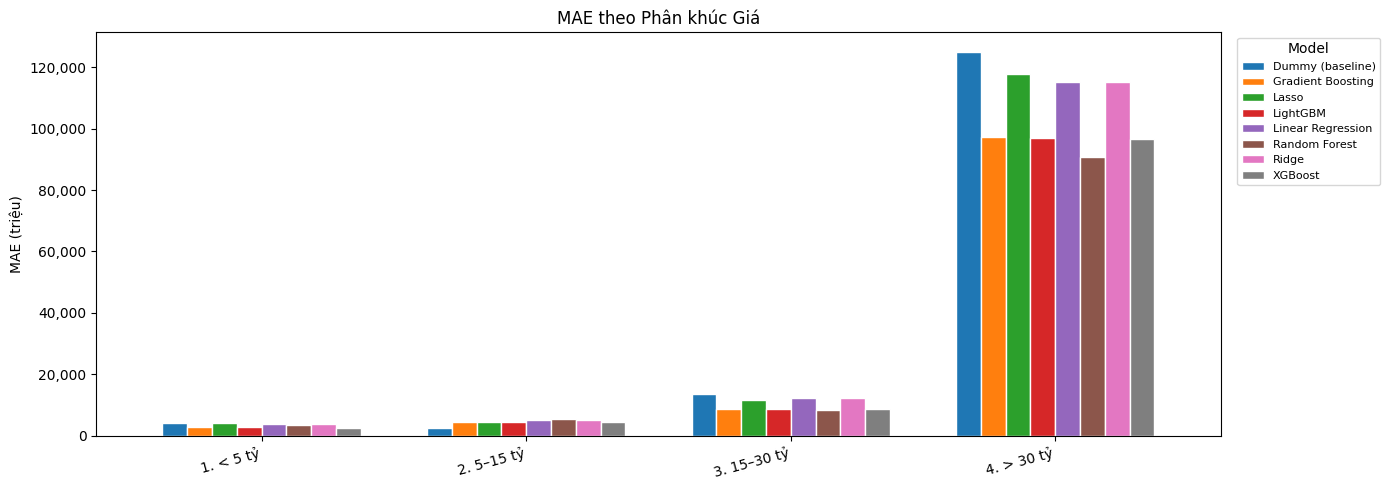

In [16]:
def price_segment(p):
    if p < 5_000:    return "1. < 5 tỷ"
    elif p < 15_000: return "2. 5–15 tỷ"
    elif p < 30_000: return "3. 15–30 tỷ"
    else:            return "4. > 30 tỷ"

seg_rows = []
for name, pd_ in model_predictions.items():
    df_s = pd.DataFrame({"Actual": y_test_real, "Pred": pd_["pred_real"]})
    df_s["Seg"] = df_s["Actual"].apply(price_segment)
    for seg, g in df_s.groupby("Seg"):
        seg_rows.append({"Model": name, "Segment": seg,
                         "MAE": mean_absolute_error(g["Actual"], g["Pred"]), "N": len(g)})
seg_piv = pd.DataFrame(seg_rows).pivot(index="Segment", columns="Model", values="MAE")
display(seg_piv.style.format("{:,.0f}").background_gradient(cmap="YlOrRd", axis=1))

fig, ax = plt.subplots(figsize=(14, 5))
seg_piv.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")
ax.set_ylabel("MAE (triệu)"); ax.set_title("MAE theo Phân khúc Giá"); ax.set_xlabel("")
ax.legend(title="Model", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()


## 14. MAE theo Quận/Huyện

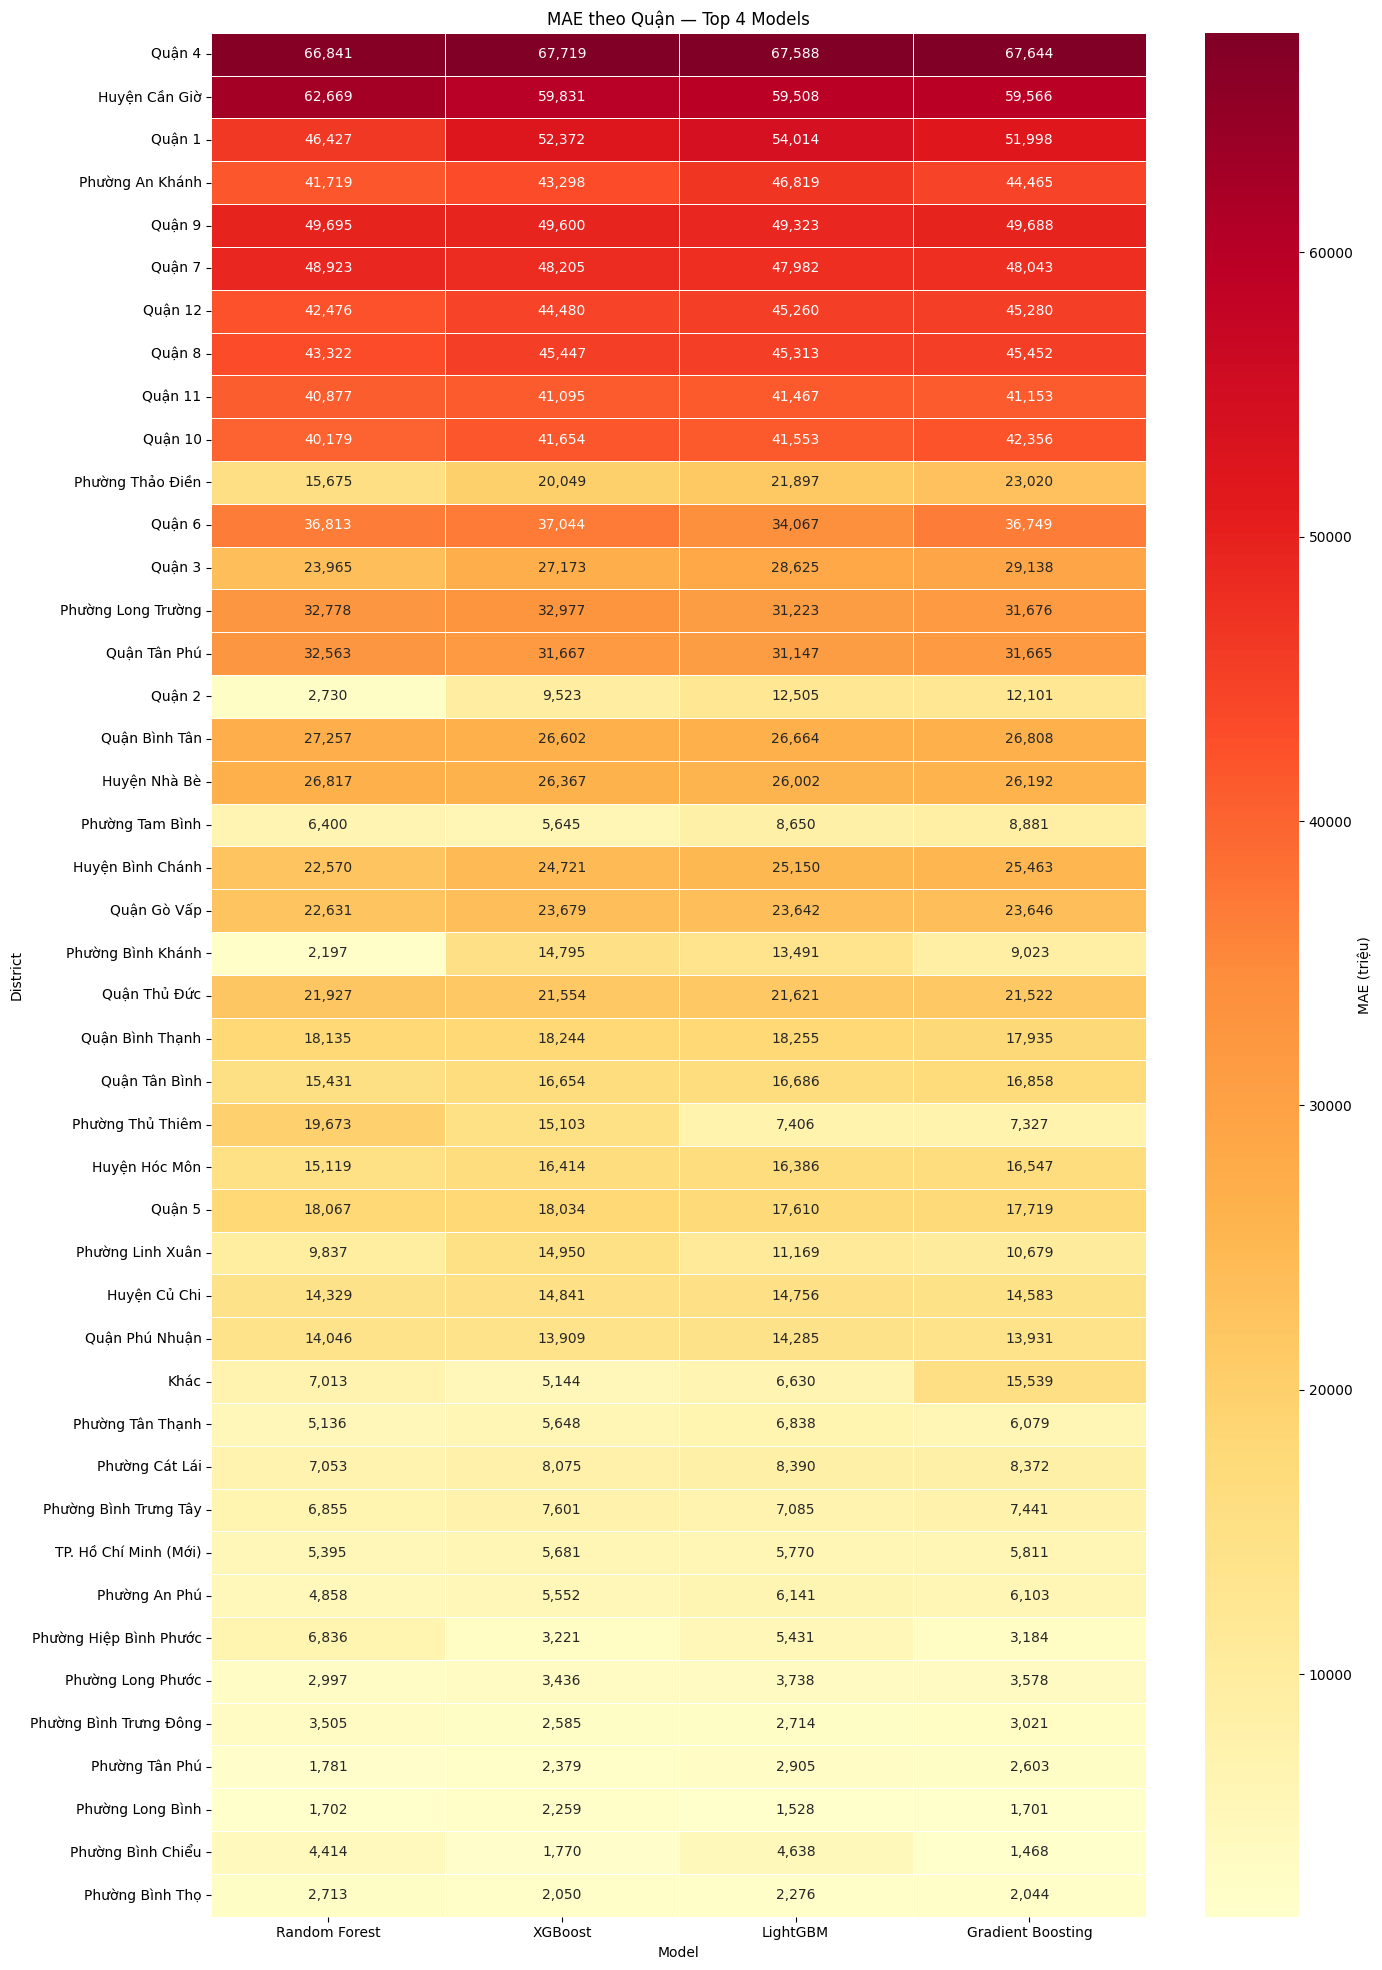

In [17]:
dist_labels = test_clean["District"].values if "District" in test_clean.columns else np.array(["Unknown"]*len(y_test_real))
dist_rows = []
for name, pd_ in model_predictions.items():
    df_d = pd.DataFrame({
        "District": test_clean.loc[y_test_real.index, "District"].values
                    if "District" in test_clean.columns
                    else np.array(["Unknown"] * len(y_test_real)),
        "Actual": y_test_real.values,
        "Pred": pd_["pred_real"]
    })
    for dist, g in df_d.groupby("District"):
        dist_rows.append({"Model": name, "District": dist,
                          "MAE": mean_absolute_error(g["Actual"], g["Pred"]), "N": len(g)})
dist_piv = pd.DataFrame(dist_rows).pivot(index="District", columns="Model", values="MAE")
dist_order = dist_piv.mean(axis=1).sort_values(ascending=False).index
dist_piv = dist_piv.loc[dist_order]

best4 = metrics_df.nsmallest(4, "Test MAE")["Model"].tolist()
heat = dist_piv[[c for c in best4 if c in dist_piv.columns]].astype(float)
fig, ax = plt.subplots(figsize=(14, max(8, len(dist_piv)*0.45)))
sns.heatmap(heat, annot=True, fmt=",.0f", cmap="YlOrRd", linewidths=0.4, ax=ax,
            cbar_kws={"label": "MAE (triệu)"})
ax.set_title("MAE theo Quận — Top 4 Models", fontsize=12)
plt.tight_layout(); plt.show()


## 15. Feature Importance — Built-in (Top 20)

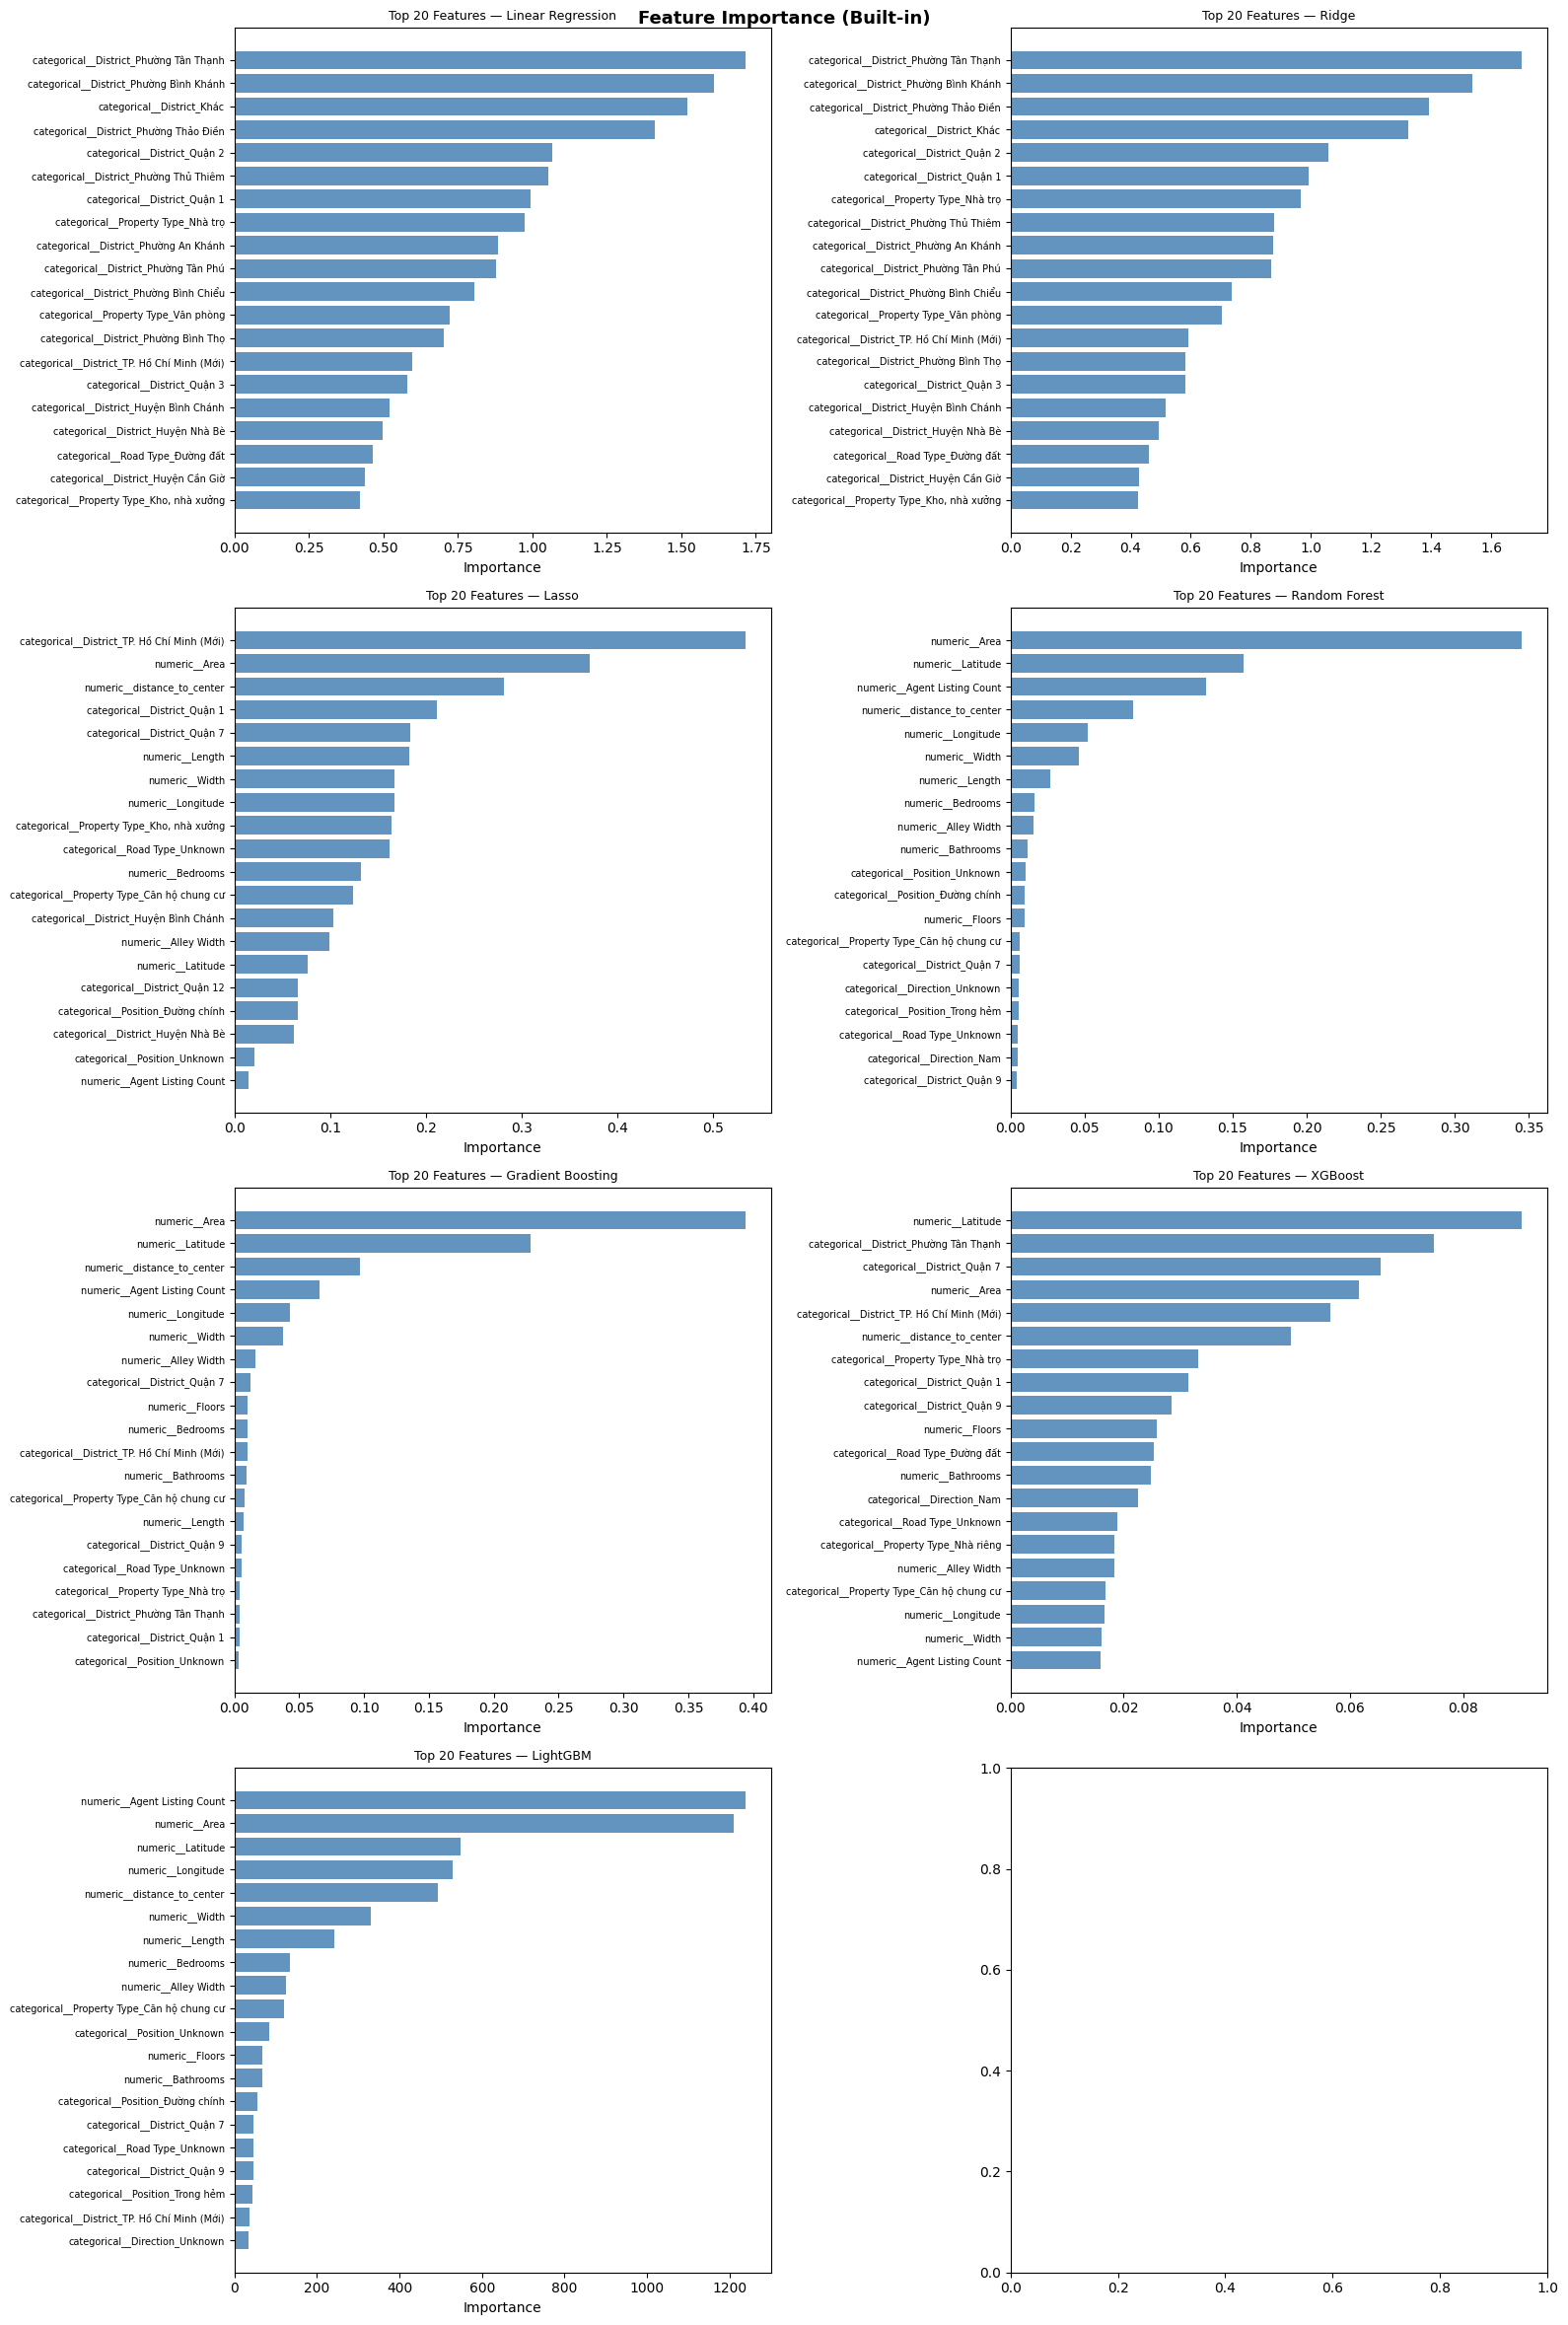

In [18]:
fi_models = {n: m for n, m in fitted_models.items()
             if hasattr(m, "feature_importances_") or hasattr(m, "coef_")}
n_fi = len(fi_models)
ncols = 2; nrows = (n_fi + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 6))
axes = axes.flat if nrows * ncols > 1 else [axes]

for ax, (name, mdl) in zip(axes, fi_models.items()):
    imp = mdl.feature_importances_ if hasattr(mdl, "feature_importances_") else np.abs(mdl.coef_.ravel())
    fi_df = (pd.DataFrame({"Feature": feature_names, "Importance": imp})
               .sort_values("Importance", ascending=False)
               .head(20).iloc[::-1])
    ax.barh(fi_df["Feature"], fi_df["Importance"], color="steelblue", alpha=0.85)
    ax.set_title(f"Top 20 Features — {name}", fontsize=9)
    ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7)

for ax in list(axes)[n_fi:]: ax.set_visible(False)
plt.suptitle("Feature Importance (Built-in)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 16. Permutation Importance — Advanced Models

Permutation importance đo mức giảm metric khi **xáo trộn ngẫu nhiên từng feature** trên test set.
Khác với built-in importance (dựa trên impurity/gain khi train), permutation importance:
- Không bị bias bởi cardinality của feature
- Đo tác động **thực tế** trên data mới
- Âm = xáo trộn feature đó giúp model tốt hơn (feature có noise)

Phần này cũng highlight **các features có importance thấp nhất** — ứng viên để loại bỏ.

In [19]:
perm_results = {}

for name in PERM_MODELS:
    if name not in fitted_models:
        print(f"  ⚠️  {name} không có trong fitted_models, bỏ qua.")
        continue
    mdl = fitted_models[name]
    print(f"  Computing permutation importance: {name} (n_repeats={N_PERM_REPS}) ...", end="", flush=True)

    # Scoring function: negative MAE on real scale
    def _neg_mae(estimator, X, y_true):
        log_pred = np.clip(estimator.predict(X), 0, LOG_CLIP_MAX)
        pred = np.expm1(log_pred) if LOG_TARGET else log_pred
        y_r  = np.expm1(y_true)  if LOG_TARGET else y_true
        return -mean_absolute_error(y_r, pred)

    pi = permutation_importance(
        mdl, X_test, y_test.values,
        scoring=_neg_mae,
        n_repeats=N_PERM_REPS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_results[name] = pi
    print(" ✅")

print("\nPermutation importance done.")


  Computing permutation importance: XGBoost (n_repeats=20) ... ✅
  Computing permutation importance: LightGBM (n_repeats=20) ... ✅
  Computing permutation importance: Gradient Boosting (n_repeats=20) ... ✅
  Computing permutation importance: Random Forest (n_repeats=20) ... ✅

Permutation importance done.


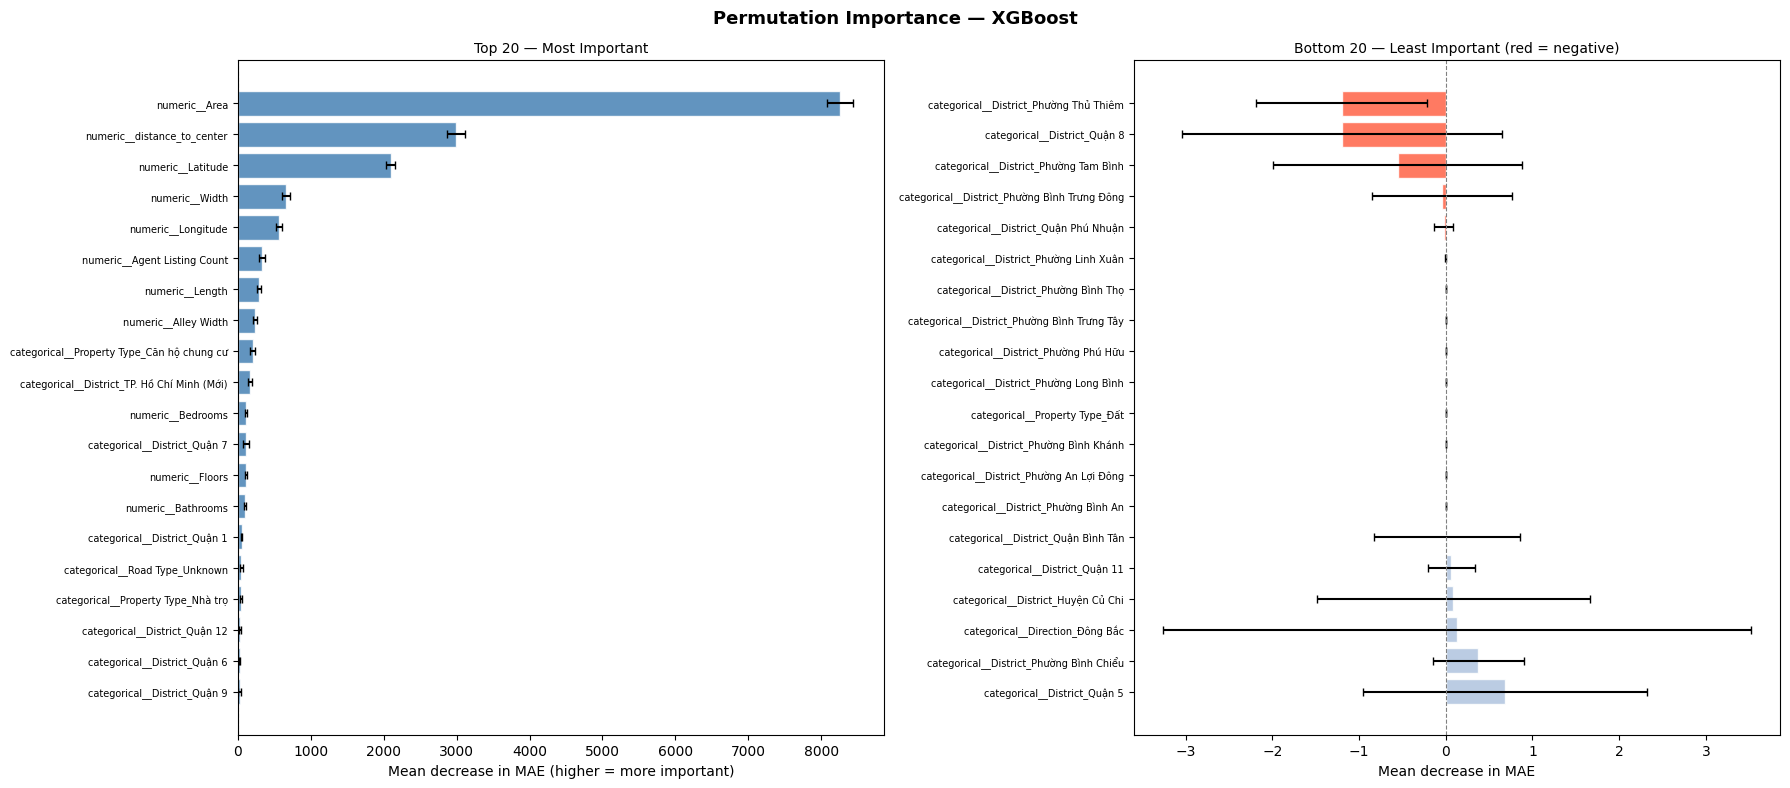

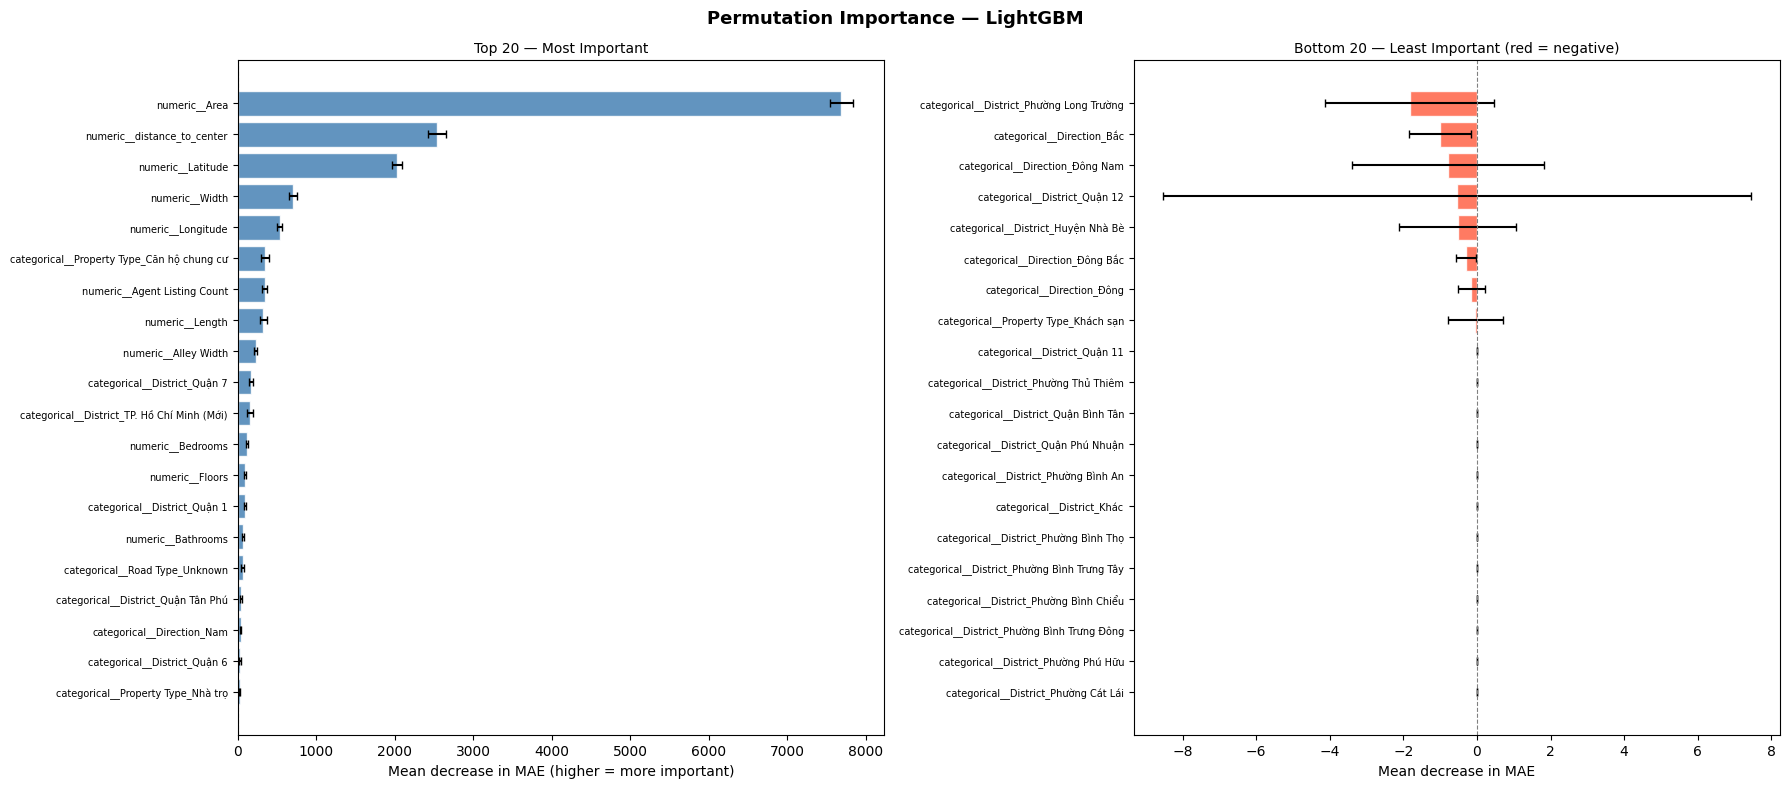

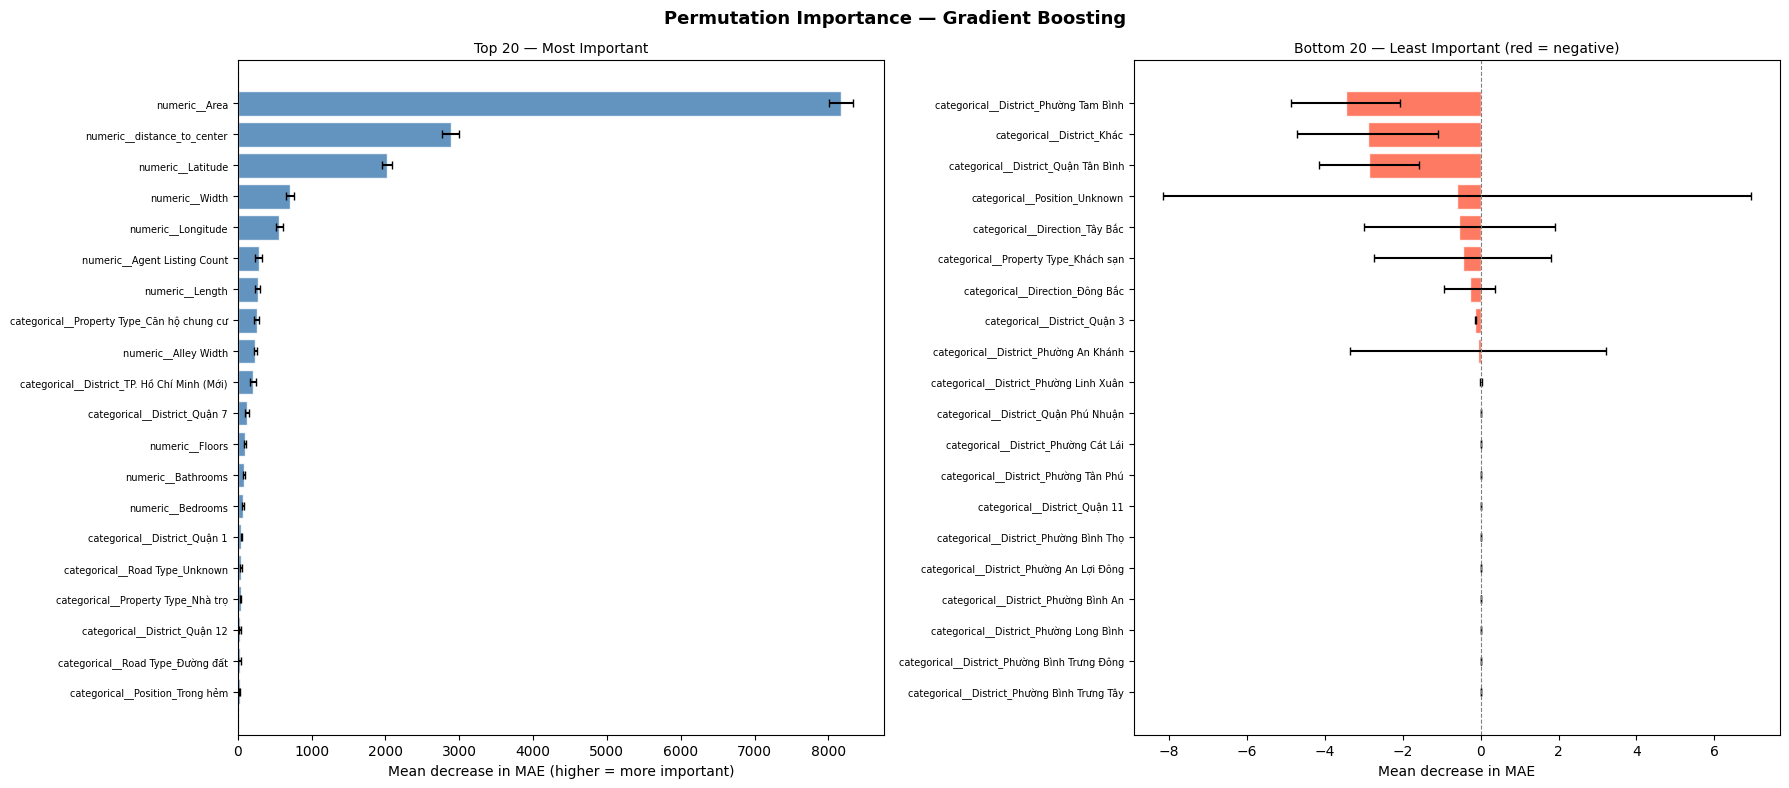

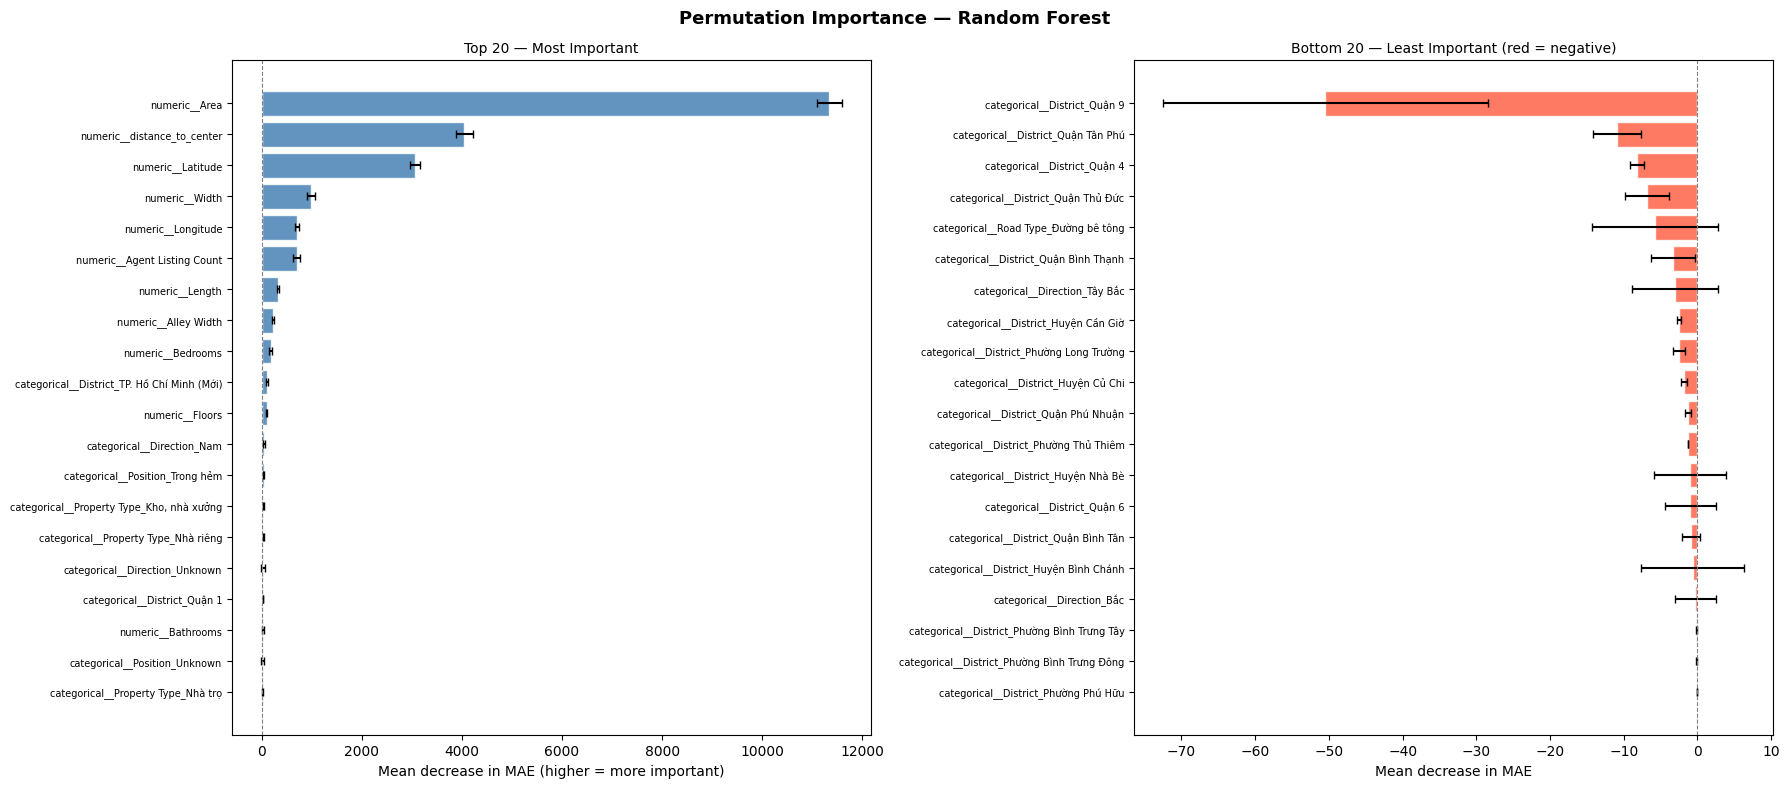

In [20]:
# ── Plot top-20 và bottom-20 per model ──────────────────────────────────────
TOP_N    = 20
BOTTOM_N = 20

for name, pi in perm_results.items():
    means = pi.importances_mean
    stds  = pi.importances_std
    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean":    means,
        "Std":     stds,
    }).sort_values("Mean", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"Permutation Importance — {name}", fontsize=13, fontweight="bold")

    # Top-20 most important
    top = fi_df.head(TOP_N).iloc[::-1]
    axes[0].barh(top["Feature"], top["Mean"], xerr=top["Std"],
                 color="steelblue", alpha=0.85, capsize=3, edgecolor="white")
    axes[0].axvline(0, color="gray", lw=0.8, ls="--")
    axes[0].set_title(f"Top {TOP_N} — Most Important", fontsize=10)
    axes[0].set_xlabel("Mean decrease in MAE (higher = more important)")
    axes[0].tick_params(axis="y", labelsize=7)

    # Bottom-20 least important (sorted ascending = least first → show on top)
    bot = fi_df.tail(BOTTOM_N).sort_values("Mean", ascending=True).iloc[::-1]
    colors = ["tomato" if v < 0 else "lightsteelblue" for v in bot["Mean"]]
    axes[1].barh(bot["Feature"], bot["Mean"], xerr=bot["Std"],
                 color=colors, alpha=0.85, capsize=3, edgecolor="white")
    axes[1].axvline(0, color="gray", lw=0.8, ls="--")
    axes[1].set_title(f"Bottom {BOTTOM_N} — Least Important (red = negative)", fontsize=10)
    axes[1].set_xlabel("Mean decrease in MAE")
    axes[1].tick_params(axis="y", labelsize=7)

    plt.tight_layout(); plt.show()


In [21]:
# ── Bảng so sánh permutation importance giữa các model ─────────────────────
perm_dfs = {}
for name, pi in perm_results.items():
    perm_dfs[name] = pd.Series(pi.importances_mean, index=feature_names, name=name)

perm_compare = pd.DataFrame(perm_dfs)

# Sắp xếp theo mean importance across models
perm_compare["_mean"] = perm_compare.mean(axis=1)
perm_compare = perm_compare.sort_values("_mean", ascending=False).drop(columns="_mean")

# Nhóm các one-hot feature thuộc cùng một biến categorical
feature_groups = []
for feat in perm_compare.index:
    if "__" in feat:
        prefix, rest = feat.split("__", 1)
        if prefix == "categorical":
            group = rest.split("_", 1)[0]
        else:
            group = rest
    elif "_" in feat:
        group = feat.split("_", 1)[0]
    else:
        group = feat
    feature_groups.append(group)

perm_compare["_group"] = feature_groups
grouped_perm = perm_compare.groupby("_group").sum()
# Keep only model columns
grouped_perm = grouped_perm[[c for c in grouped_perm.columns if c in perm_results.keys()]]

# Sort by average importance across models
grouped_perm["_mean"] = grouped_perm.mean(axis=1)
grouped_perm = grouped_perm.sort_values("_mean", ascending=False).drop(columns="_mean")

print(f"=== Permutation Importance — Top 20 Features ===")
# display per-feature importance (exclude internal _group column for styling)
display(perm_compare.drop(columns=["_group"], errors="ignore").head(20).style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=None))

print(f"\n=== Permutation Importance — Top 10 Feature Groups (One-Hot grouped by original variable) ===")
# grouped_perm is numeric so safe to format
display(grouped_perm.head(10).style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=None))

print(f"\n=== Bottom 10 Feature Groups (ứng viên loại bỏ) ===")
display(grouped_perm.tail(10).sort_values(list(grouped_perm.columns)[0]).style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=None))

=== Permutation Importance — Top 20 Features ===


,XGBoost,LightGBM,Gradient Boosting,Random Forest
numeric__Area,8258.2629,7686.5906,8168.8304,11336.2904
numeric__distance_to_center,2987.4305,2536.0892,2884.4938,4053.2438
numeric__Latitude,2095.1992,2030.6837,2020.7741,3060.7800
numeric__Width,665.4020,705.1557,709.9312,982.8179
numeric__Longitude,565.6684,532.1573,563.3991,707.7258
numeric__Agent Listing Count,334.2307,344.0979,282.9488,703.2574
numeric__Length,287.1807,328.1312,269.9713,328.7823
numeric__Alley Width,236.0649,231.6914,237.3728,233.5020
categorical__Property Type_Căn hộ chung cư,202.8748,344.7264,255.7366,4.2667
categorical__District_TP. Hồ Chí Minh (Mới),169.0561,159.7135,207.3764,108.8251



=== Permutation Importance — Top 10 Feature Groups (One-Hot grouped by original variable) ===


,XGBoost,LightGBM,Gradient Boosting,Random Forest
_group,,,,
Area,8258.2629,7686.5906,8168.8304,11336.2904
distance_to_center,2987.4305,2536.0892,2884.4938,4053.2438
Latitude,2095.1992,2030.6837,2020.7741,3060.7800
Width,665.4020,705.1557,709.9312,982.8179
Longitude,565.6684,532.1573,563.3991,707.7258
District,549.4344,601.7005,499.6158,123.4987
Agent Listing Count,334.2307,344.0979,282.9488,703.2574
Length,287.1807,328.1312,269.9713,328.7823
Property Type,291.7160,409.0773,335.4248,108.0164



=== Bottom 10 Feature Groups (ứng viên loại bỏ) ===


,XGBoost,LightGBM,Gradient Boosting,Random Forest
_group,,,,
Position,27.9619,52.3779,27.9148,77.1631
Direction,37.8659,37.5877,19.4412,87.9439
Road Type,89.5370,88.0671,89.2927,22.1091
Bathrooms,101.2195,70.2727,84.5362,26.9435
Floors,112.5838,93.7531,95.9140,99.9976
Bedrooms,118.5733,112.5786,71.5440,179.8614
Alley Width,236.0649,231.6914,237.3728,233.5020
Length,287.1807,328.1312,269.9713,328.7823
Property Type,291.7160,409.0773,335.4248,108.0164


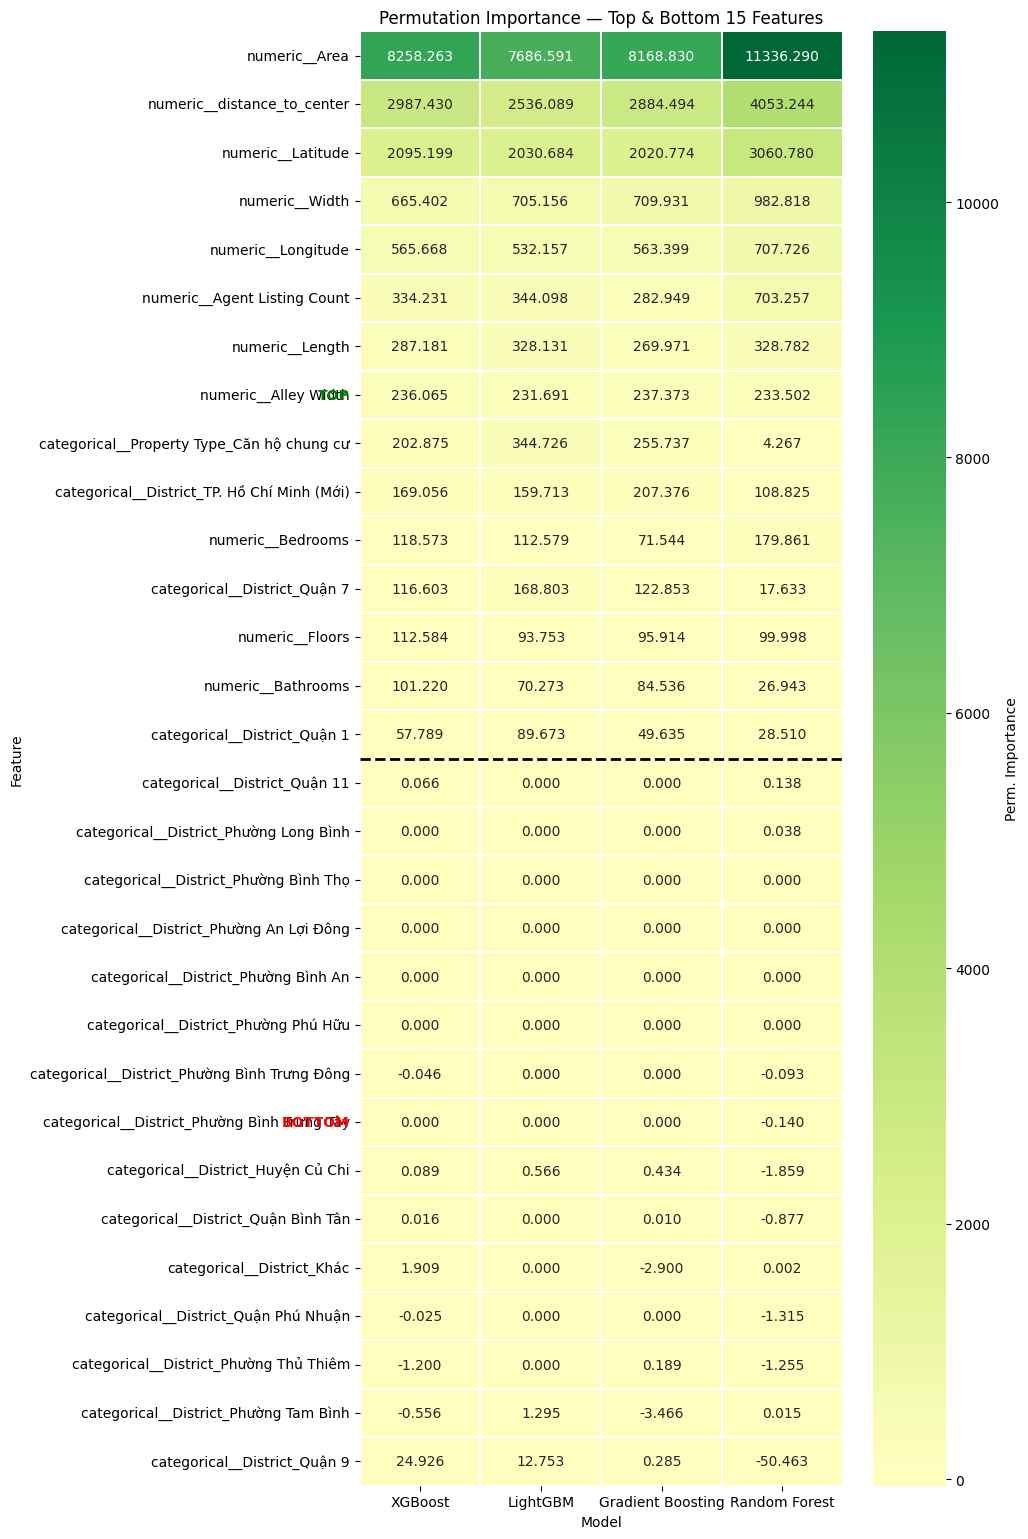

In [22]:
# ── Heatmap tổng hợp permutation importance: top + bottom 15 ──────────────
n_show = 15
top_feats = perm_compare.head(n_show).index.tolist()
bot_feats = perm_compare.tail(n_show).index.tolist()
show_feats = top_feats + bot_feats
heat_perm = perm_compare.loc[show_feats]

fig, ax = plt.subplots(figsize=(max(8, len(perm_results)*2.5), len(show_feats)*0.45 + 2))
sns.heatmap(heat_perm.drop(columns="_group"), annot=True, fmt=".3f", cmap="RdYlGn",
                        center=0, linewidths=0.3, ax=ax, cbar_kws={"label": "Perm. Importance"})
ax.axhline(n_show, color="black", lw=2, ls="--")
ax.text(-0.02, n_show / 2, "TOP", transform=ax.get_yaxis_transform(),
        ha="right", va="center", fontsize=10, color="green", fontweight="bold")
ax.text(-0.02, n_show + n_show / 2, "BOTTOM", transform=ax.get_yaxis_transform(),
        ha="right", va="center", fontsize=10, color="red", fontweight="bold")
ax.set_title(f"Permutation Importance — Top & Bottom {n_show} Features", fontsize=12)
ax.set_ylabel("Feature"); ax.set_xlabel("Model")
plt.tight_layout(); plt.show()


In [23]:
# ── Đề xuất features cần xem xét loại bỏ ──────────────────────────────────
# Feature bị coi là "low importance" nếu mean perm importance <= 0 ở >= 50% models
n_models = len(perm_results)
# Use numeric-only perm_compare (exclude internal grouping column)
numeric_perm = perm_compare.drop(columns=["_group"], errors="ignore")
neg_count = (numeric_perm <= 0).sum(axis=1)
# Select candidates from numeric_perm
candidates = numeric_perm[neg_count >= n_models * 0.5].sort_values(
    numeric_perm.columns[0] if len(numeric_perm.columns) else None
)
if len(candidates):
    print(f"⚠️  Features có permutation importance ≤ 0 ở ≥ 50% models ({n_models} models):")
    print(f"   → Ứng viên xem xét loại bỏ:\n")
    display(candidates.style.format("{:.4f}").background_gradient(cmap="Reds_r", axis=None))
else:
    print("✅ Không có feature nào có importance ≤ 0 ở đa số models.")

⚠️  Features có permutation importance ≤ 0 ở ≥ 50% models (4 models):
   → Ứng viên xem xét loại bỏ:



,XGBoost,LightGBM,Gradient Boosting,Random Forest
categorical__District_Phường Thủ Thiêm,-1.2000,0.0000,0.1888,-1.2553
categorical__District_Phường Tam Bình,-0.5556,1.2955,-3.4662,0.0155
categorical__District_Phường Bình Trưng Đông,-0.0455,0.0000,0.0000,-0.0926
categorical__District_Quận Phú Nhuận,-0.0255,0.0000,0.0000,-1.3148
categorical__District_Phường Linh Xuân,-0.0026,0.0000,-0.0005,1.3142
categorical__Property Type_Đất,0.0000,0.0000,7.4707,10.7653
categorical__District_Phường Phú Hữu,0.0000,0.0000,0.0000,0.0000
categorical__District_Phường Bình An,0.0000,0.0000,0.0000,0.0000
categorical__District_Phường Bình Thọ,0.0000,0.0000,0.0000,0.0002
categorical__District_Phường An Lợi Đông,0.0000,0.0000,0.0000,0.0000


## 17. Lưu Models (pkl) — Random Forest, Gradient Boosting, XGBoost, LightGBM

In [24]:
saved_paths = {}
for name, mdl in fitted_models.items():
    if name not in SAVE_MODELS:
        continue
    safe_name = name.lower().replace(" ", "_")
    path = MODEL_DIR / f"{safe_name}.pkl"
    # Save model + encode pipeline + preprocessor as a bundle
    bundle = {
        "model":            mdl,
        "encode_pipeline":  encode_pipeline,
        "preprocessor":     preprocessor,
        "feature_names":    feature_names,
        "log_target":       LOG_TARGET,
        "metrics": {
            k: v for row in metrics_list if row["Model"] == name
            for k, v in row.items() if k != "Model"
        },
    }
    joblib.dump(bundle, path, compress=3)
    saved_paths[name] = path
    size_kb = path.stat().st_size / 1024
    print(f"  ✅  {name:<22} → {path}  ({size_kb:,.0f} KB)")

print("\nTất cả models đã được lưu.")


  ✅  Random Forest          → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\models\random_forest.pkl  (153,773 KB)
  ✅  Gradient Boosting      → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\models\gradient_boosting.pkl  (309 KB)
  ✅  XGBoost                → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\models\xgboost.pkl  (267 KB)
  ✅  LightGBM               → C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\models\lightgbm.pkl  (224 KB)

Tất cả models đã được lưu.


In [25]:
# ── Verify load & predict ──────────────────────────────────────────────────
print("=== Kiểm tra load pkl và predict ===")
for name, path in saved_paths.items():
    bundle = joblib.load(path)
    mdl_loaded = bundle["model"]
    pred_log   = np.clip(mdl_loaded.predict(X_test), 0, LOG_CLIP_MAX)
    pred_real  = np.expm1(pred_log) if bundle["log_target"] else pred_log
    mae_loaded = mean_absolute_error(y_test_real, pred_real)
    mae_orig   = metrics_df[metrics_df["Model"] == name]["Test MAE"].values[0]
    match = abs(mae_loaded - mae_orig) < 0.01
    print(f"  {'✅' if match else '❌'}  {name:<22}  MAE loaded={mae_loaded:,.1f}  orig={mae_orig:,.1f}")


=== Kiểm tra load pkl và predict ===
  ✅  Random Forest           MAE loaded=21,124.7  orig=21,124.7
  ✅  Gradient Boosting       MAE loaded=21,722.2  orig=21,722.2
  ✅  XGBoost                 MAE loaded=21,598.5  orig=21,598.5
  ✅  LightGBM                MAE loaded=21,667.8  orig=21,667.8


## 18. Tóm tắt kết quả

In [26]:
print("=" * 70)
print("TỔNG KẾT — XẾP HẠNG THEO TEST MAE")
print("=" * 70)
ranked = metrics_df.sort_values("Test MAE").reset_index(drop=True)
ranked.index += 1
for _, row in ranked.iterrows():
    saved = "💾" if row["Model"] in SAVE_MODELS else "  "
    print(f"  #{int(row.name):2d} {saved}  {row['Model']:25s}"
          f"  MAE={row['Test MAE']:>8,.0f}"
          f"  RMSE={row['Test RMSE']:>8,.0f}"
          f"  R²={row['Test R²']:.4f}"
          f"  MAPE={row['Test MAPE (%)']:.2f}%")

best = ranked.iloc[0]
print(f"\n🏆 Best: {best['Model']}")
print(f"   MAE={best['Test MAE']:,.0f} triệu  RMSE={best['Test RMSE']:,.0f} triệu  R²={best['Test R²']:.4f}  MAPE={best['Test MAPE (%)']:.2f}%")
print(f"\n💾 Saved models: {', '.join(saved_paths.keys())}")
print(f"   Directory    : {MODEL_DIR.resolve()}")
print("=" * 70)


TỔNG KẾT — XẾP HẠNG THEO TEST MAE
  # 1 💾  Random Forest              MAE=  21,125  RMSE=  71,434  R²=0.1752  MAPE=89.96%
  # 2 💾  XGBoost                    MAE=  21,598  RMSE=  72,949  R²=0.1398  MAPE=74.72%
  # 3 💾  LightGBM                   MAE=  21,668  RMSE=  73,320  R²=0.1310  MAPE=75.35%
  # 4 💾  Gradient Boosting          MAE=  21,722  RMSE=  73,119  R²=0.1358  MAPE=76.06%
  # 5     Linear Regression          MAE=  26,180  RMSE=  84,151  R²=-0.1446  MAPE=111.45%
  # 6     Ridge                      MAE=  26,185  RMSE=  84,158  R²=-0.1448  MAPE=111.46%
  # 7     Lasso                      MAE=  26,564  RMSE=  82,684  R²=-0.1051  MAPE=118.71%
  # 8     Dummy (baseline)           MAE=  27,544  RMSE=  82,237  R²=-0.0932  MAPE=127.85%

🏆 Best: Random Forest
   MAE=21,125 triệu  RMSE=71,434 triệu  R²=0.1752  MAPE=89.96%

💾 Saved models: Random Forest, Gradient Boosting, XGBoost, LightGBM
   Directory    : C:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\artifacts\mo